![Screenshot-63.png](https://i.postimg.cc/rm3hj7jZ/Screenshot-63.png)

# DATA SCIENTIST: Tega Jarikre
# PROJECT: Kaggle Competition
# PROJECT NAME: House Prices - Advanced Regression Techniques
# PROJECT URL: https://www.kaggle.com/c/house-prices-advanced-regression-techniques
# PROJECT DESCRIPTION: With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.
# PROJECT DURATION: 2Weeks
# PROJECT START DATE: 08-14-2025
# SUBMISSION STATUS: Submitted
# PROJECT END DATE: 08-23-2025

## Tools/libs to be used
* Numpy
* Pandas
* Matplotlib
* Seaborn
* Skit-Learn
* XGBoost

In [163]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import RFE
from sklearn import metrics
# Importing XGBoost
from xgboost import XGBRegressor
# Importing LightGBM
from lightgbm import LGBMRegressor

## 1. UNDERSTANDING THE DATASETS AND THEIR STRUCTURE

* How many columns are in the datasets?
* What are the datatypes? Are they accurate?
* Are there missing values in the datasets?

In [164]:
# Reading the datasets
trainset_df = pd.read_csv("C:/Users/USER/Downloads/house-prices-advanced-regression-techniques/train.csv")
testset_df = pd.read_csv("C:/Users/USER/Downloads/house-prices-advanced-regression-techniques/test.csv")

In [165]:
#Viewing the shape of the datasets
print("Train set shape:", trainset_df.shape)
print("Test set shape:", testset_df.shape)

Train set shape: (1460, 81)
Test set shape: (1459, 80)


In [166]:
#Setting the display options for better readability
pd.set_option('display.max_columns', None)  # Show all columns

## The Trainset and its Structure

In [167]:
#Viewing the first few rows of the train set
print("\nTrain set preview:")
trainset_df.head()


Train set preview:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [168]:
#Viewing the information about the train set
print("\nTrain set info:")
print(trainset_df.info())


Train set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int6

In [169]:
#Viewing instances of duplication withing trainset
print("\nDuplication within trainset data:")
print(trainset_df.duplicated().any())



Duplication within trainset data:
False


In [170]:
#Viewing columns with missing values
trainset_cols_with_na = trainset_df.columns[trainset_df.isnull().any()]
print(f'Number of columns with missing values: \n{len(trainset_cols_with_na)}')
print()
print(f'Columns with missing values: \n{list(trainset_cols_with_na)}')

#Viewing each column with na and their counts
print()
print(f'Each column with na and their number of missing values: \n{trainset_df.isnull().sum()[trainset_df.isnull().sum() > 0]}')

#Viewing each column with na and their percentages
print()
print(f'Each column with na and their percentage of missing values: \n{(trainset_df.isnull().mean()*100)[trainset_df.isnull().mean() > 0]}')

Number of columns with missing values: 
19

Columns with missing values: 
['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

Each column with na and their number of missing values: 
LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Each column with na and their percentage of missing values: 
LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
Bsm

In [171]:
print("Trainset columns and methods to handle missing values: \n")
num_train_cols_to_fill = []
num_train_cols_to_drop = []
cat_train_cols_to_fill = []
cat_train_cols_to_replace = []
for col in trainset_cols_with_na:
    if trainset_df[col].dtype == 'int64' or trainset_df[col].dtype == 'float64':
        print("="*25, col, '='*25)
        print(f"{col} data is numeric.")
        print()
        if trainset_df[col].isnull().mean()*100 > 50:
            print(f'{col} will be dropped.')
            num_train_cols_to_drop.append(col)
        else:
            print(f'Missing values in {col} will be handled by grouped median.')
            num_train_cols_to_fill.append(col)
    elif trainset_df[col].dtype == 'object':
        print("="*25, col, '='*25)
        print("Number of unique values: ", trainset_df[col].nunique())
        print()
        print(trainset_df[col].value_counts())
        if trainset_df[col].isnull().mean()*100 > 40:
            print(f'Missing values in {col} will be replaced with "No {col}".')
            cat_train_cols_to_replace.append(col)
        else:
            print(f'Missing values in {col} will be handled by grouped mode.')
            cat_train_cols_to_fill.append(col)
    else:
        print(f'{col} is not numeric or object')

Trainset columns and methods to handle missing values: 

========================= LotFrontage =========================
LotFrontage data is numeric.

Missing values in LotFrontage will be handled by grouped median.
========================= Alley =========================
Number of unique values:  2

Alley
Grvl    50
Pave    41
Name: count, dtype: int64
Missing values in Alley will be replaced with "No Alley".
========================= MasVnrType =========================
Number of unique values:  3

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64
Missing values in MasVnrType will be replaced with "No MasVnrType".
========================= MasVnrArea =========================
MasVnrArea data is numeric.

Missing values in MasVnrArea will be handled by grouped median.
========================= BsmtQual =========================
Number of unique values:  4

BsmtQual
TA    649
Gd    618
Ex    121
Fa     35
Name: count, dtype: int64
Missing values in Bsmt

In [172]:
trainset_df['Utilities'].value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

In [173]:
print("Numeric trainset columns with na to fill by grouped median: \n", num_train_cols_to_fill)
print("Numeric trainset columns with na to drop: \n", num_train_cols_to_drop)
print("Categorical trainset columns with na to fill by grouped mode: \n", cat_train_cols_to_fill)
print("Categorical trainset columns with na to replace: \n", cat_train_cols_to_replace)


Numeric trainset columns with na to fill by grouped median: 
 ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
Numeric trainset columns with na to drop: 
 []
Categorical trainset columns with na to fill by grouped mode: 
 ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
Categorical trainset columns with na to replace: 
 ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


## The Testset and its Structure

In [174]:
#Viewing the first few rows of the test set
print("\nTest set preview:")
testset_df.head()


Test set preview:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [175]:
#Viewing the information about the test set
print("\nTest set info:")
print(testset_df.info())



Test set info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64

In [176]:
#Viewing instances of duplication within testset
print("\nDuplication within testset data:")
print(testset_df.duplicated().any())



Duplication within testset data:
False


In [177]:
#Viewing columns with missing values in the testset
testset_cols_with_na = testset_df.columns[testset_df.isnull().any()]
print(f'Number of columns with missing values: \n{len(testset_cols_with_na)}')
print()
print(f'Columns with missing values: \n{list(testset_cols_with_na)}')

#Viewing each column with na and their counts
print()
print(f'Each column with na and their number of missing values: \n{testset_df.isnull().sum()[testset_df.isnull().sum() > 0]}')

#Viewing each column with na and their percentages
print()
print(f'Each column with na and their percentage of missing values: \n{(testset_df.isnull().mean()*100)[testset_df.isnull().mean() > 0]}')

Number of columns with missing values: 
33

Columns with missing values: 
['MSZoning', 'LotFrontage', 'Alley', 'Utilities', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType']

Each column with na and their number of missing values: 
MSZoning           4
LotFrontage      227
Alley           1352
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType       894
MasVnrArea        15
BsmtQual          44
BsmtCond          45
BsmtExposure      44
BsmtFinType1      42
BsmtFinSF1         1
BsmtFinType2      42
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQua

In [181]:
#Iteratin through the testset to determine columns with na to be dropped, filled or replaced
print("Testset columns and methods to handle missing values: \n")
num_test_cols_to_fill = []
num_test_cols_to_drop = []
cat_test_cols_to_fill = []
cat_test_cols_to_replace = []
for col in testset_cols_with_na:
    if testset_df[col].dtype == 'int64' or testset_df[col].dtype == 'float64':
        print("="*25, col, '='*25)
        print(f"{col} data is numeric.")
        print()
        if testset_df[col].isnull().mean()*100 > 50:
            print(f'{col} will be dropped.')
            num_test_cols_to_drop.append(col)
        else:
            print(f'Missing values in {col} will be handled by grouped median.')
            num_test_cols_to_fill.append(col)
    elif testset_df[col].dtype == 'object':
        print("="*25, col, '='*25)
        print("Number of unique values: ", testset_df[col].nunique())
        print()
        print(testset_df[col].value_counts())
        if testset_df[col].isnull().mean()*100 > 40:
           
            print(f'Missing values in {col} will be replaced with "No {col}".')
            cat_test_cols_to_replace.append(col)
        else:
            print(f'Missing values in {col} will be handled by grouped mode.')
            cat_test_cols_to_fill.append(col)
    else:
        print(f'{col} is not numeric or object')

Testset columns and methods to handle missing values: 

========================= MSZoning =========================
Number of unique values:  5

MSZoning
RL         1114
RM          242
FV           74
C (all)      15
RH           10
Name: count, dtype: int64
Missing values in MSZoning will be handled by grouped mode.
========================= LotFrontage =========================
LotFrontage data is numeric.

Missing values in LotFrontage will be handled by grouped median.
========================= Alley =========================
Number of unique values:  2

Alley
Grvl    70
Pave    37
Name: count, dtype: int64
Missing values in Alley will be replaced with "No Alley".
========================= Utilities =========================
Number of unique values:  1

Utilities
AllPub    1457
Name: count, dtype: int64
Missing values in Utilities will be handled by grouped mode.
========================= Exterior1st =========================
Number of unique values:  13

Exterior1st
VinylSd    5

In [182]:
print("Numeric testset columns with na to fill by grouped median: \n", num_test_cols_to_fill)
print("Numeric testset columns with na to drop: \n", num_test_cols_to_drop)
print("Categorical testset columns with na to fill by grouped mode: \n", cat_test_cols_to_fill)
print("Categorical testset columns with na to replace: \n", cat_test_cols_to_replace)

Numeric testset columns with na to fill by grouped median: 
 ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea']
Numeric testset columns with na to drop: 
 []
Categorical testset columns with na to fill by grouped mode: 
 ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'SaleType']
Categorical testset columns with na to replace: 
 ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


# 2.DATA CLEANING
NB:
* Duplication: False
* Missing Values: True
* Data Types: Correct

* Question: What's the best method for handling missing data? 
* Answer: Grouped median/mode
* Justification: Preservation of data patterns and avoiding bias

* Feature to group by: SaleCondition

## Handling Missing Data

### i. Handling missing data in trainset

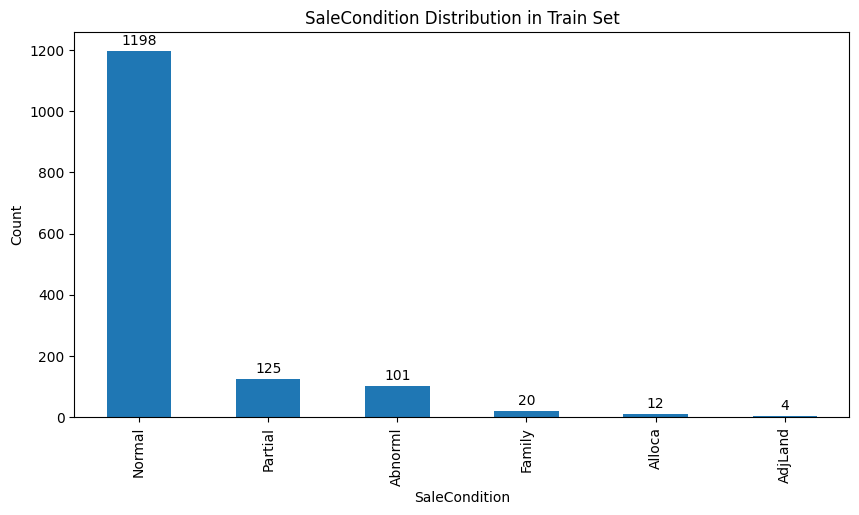

In [183]:
#Viewing the distribution of SaleCondition in the trainset
trainset_df["SaleCondition"].value_counts().plot(kind='bar', figsize=(10, 5), title='SaleCondition Distribution in Train Set')
plt.xlabel('SaleCondition')
plt.ylabel('Count')
#Showing the values on the bars
for i, v in enumerate(trainset_df["SaleCondition"].value_counts()):
    plt.text(i, v + 10, str(v), ha='center', va='bottom')

plt.show()

In [184]:
#Viewing the proposed methods for handling missing data in trainset
print("Numeric trainset columns with na to fill by grouped median: \n", num_train_cols_to_fill)
print("Numeric trainset columns with na to drop: \n", num_train_cols_to_drop)
print("Categorical trainset columns with na to fill by grouped mode: \n", cat_train_cols_to_fill)
print("Categorical trainset columns with na to replace: \n", cat_train_cols_to_replace)

Numeric trainset columns with na to fill by grouped median: 
 ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
Numeric trainset columns with na to drop: 
 []
Categorical trainset columns with na to fill by grouped mode: 
 ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
Categorical trainset columns with na to replace: 
 ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


In [185]:
#Filling numerical trainset columns with na by grouped median using "SaleCondition"
for col in num_train_cols_to_fill:
    trainset_df[col] = trainset_df.groupby('SaleCondition')[col].transform(lambda x: x.fillna(x.median()))

for col in num_train_cols_to_fill:
    print(trainset_df[col].isnull().sum())

0
0
0


In [186]:
#Filling categorical trainset columns with na by grouped mode using "SaleCondition"
for col in cat_train_cols_to_fill:
    trainset_df[col] = trainset_df[col].fillna(trainset_df.groupby('SaleCondition')[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))

#Confirming if na has been filled
for col in cat_train_cols_to_fill:
    print(trainset_df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0


In [187]:
#Filling categorical trainset columns with na by replacing with "No {col}"
for col in cat_train_cols_to_replace:
    trainset_df[col] = trainset_df[col].fillna(f'No {col}')
#Confirming if na has been filled
for col in cat_train_cols_to_replace:
    print(trainset_df[col].isnull().sum())

0
0
0
0
0
0


In [188]:
#Rechecking the trainset for any remaining na
print("Sum of missing values in trainset:") 
print(trainset_df.isnull().sum().sum())

Sum of missing values in trainset:
0


### ii. Handling missing data in testset

In [189]:
#Viewing the proposed methods of handling missing data in testset
print("Numeric testset columns with na to fill by grouped median: \n", num_test_cols_to_fill)
print("Numeric testset columns with na to drop: \n", num_test_cols_to_drop)
print("Categorical testset columns with na to fill by grouped mode: \n", cat_test_cols_to_fill)
print("Categorical testset columns with na to replace: \n", cat_test_cols_to_replace)

Numeric testset columns with na to fill by grouped median: 
 ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea']
Numeric testset columns with na to drop: 
 []
Categorical testset columns with na to fill by grouped mode: 
 ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'SaleType']
Categorical testset columns with na to replace: 
 ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


In [190]:
#Filling numerical testset columns with na by grouped median using "SaleCondition"
for col in num_test_cols_to_fill:
    testset_df[col] = testset_df.groupby('SaleCondition')[col].transform(lambda x: x.fillna(x.median()))

for col in num_test_cols_to_fill:
    print(testset_df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0
0


In [192]:
#Filling categorical testset columns with na by grouped mode using "SaleCondition"
for col in cat_test_cols_to_fill:
    testset_df[col] = testset_df[col].fillna(testset_df.groupby('SaleCondition')[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))

#Confirming if na has been filled
for col in cat_test_cols_to_fill:
    print(testset_df[col].isnull().sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [193]:
#Filling categorical testset columns with na by replacing with "No {col}"
for col in cat_test_cols_to_replace:
    testset_df[col] = testset_df[col].fillna(f'No {col}')
#Confirming if na has been filled
for col in cat_test_cols_to_replace:
    print(testset_df[col].isnull().sum())

0
0
0
0
0
0


In [194]:
#Rechecking the testset for any remaining na
print("Sum of missing values in testset:")
print(testset_df.isnull().sum().sum()) 


Sum of missing values in testset:
0


# 3. EXPLORATORY DATA ANALYSIS

## i. EDA on Trainset

In [195]:
#Creating separate DataFrames for numerical and categorical columns in the trainset
num_trainset_df = trainset_df.drop(columns=['Id'], axis=1).select_dtypes(include=['int64', 'float64'])
cat_trainset_df = trainset_df.select_dtypes(include=['object'])

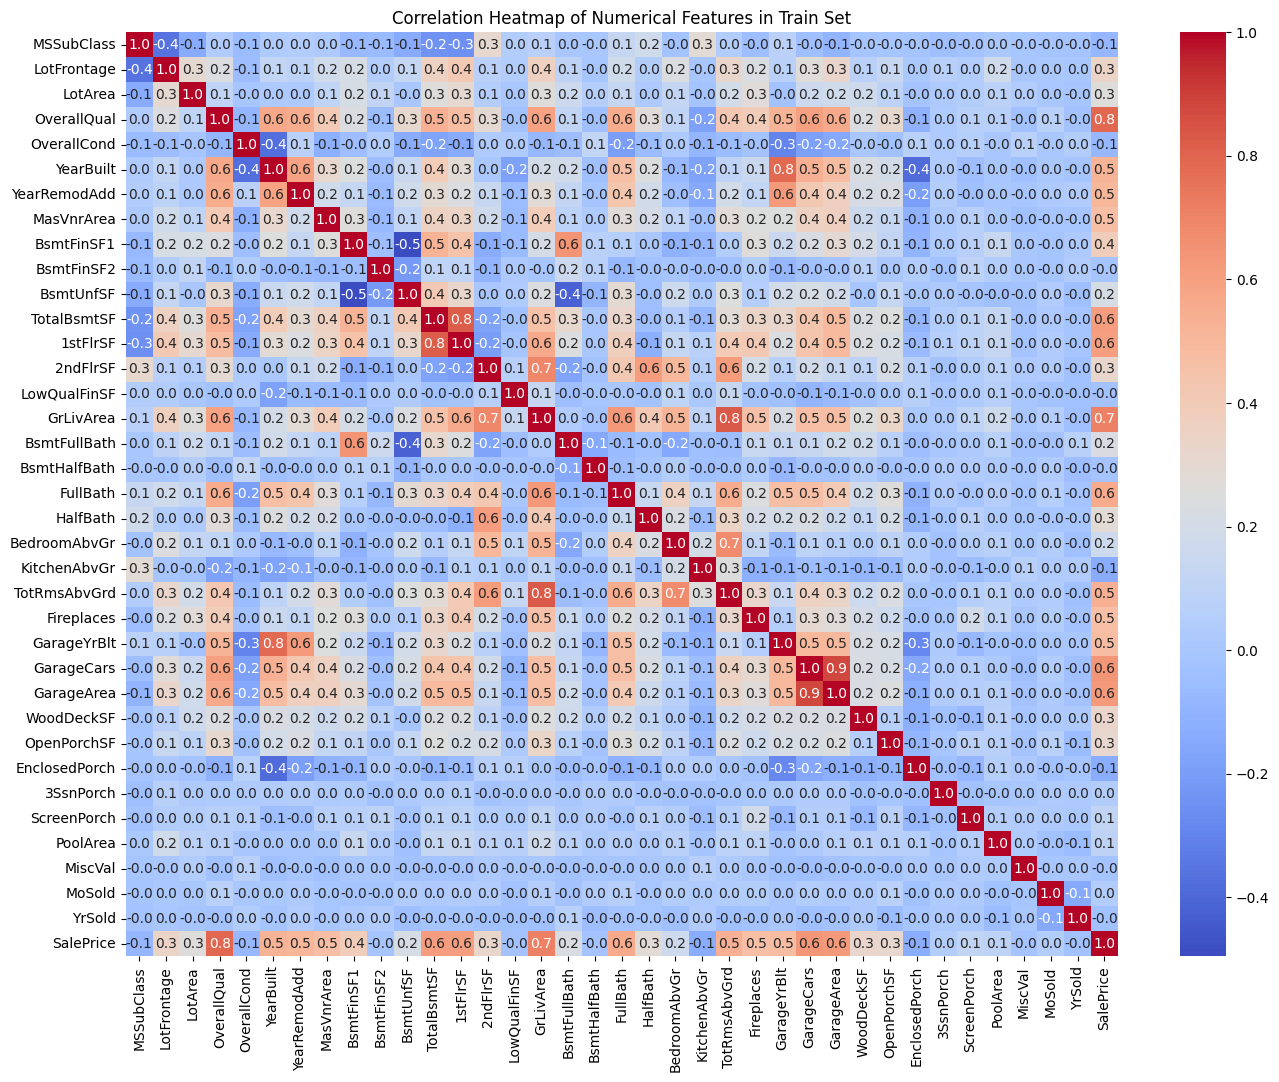

In [196]:
plt.figure(figsize=(16, 12)) 
sns.heatmap(data = num_trainset_df.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features in Train Set')
plt.show()

In [197]:
#Viewing the correlation of numerical features with 'SalePrice' in the trainset
train_correlation_with_saleprice = num_trainset_df.corr()['SalePrice'].sort_values(ascending=False)
print("Correlation of features with 'SalePrice' in the trainset: \n", train_correlation_with_saleprice)

Correlation of features with 'SalePrice' in the trainset: 
 SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.477264
MasVnrArea       0.474284
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334740
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
Kitc

In [198]:
num_trainset_df.shape

(1460, 37)

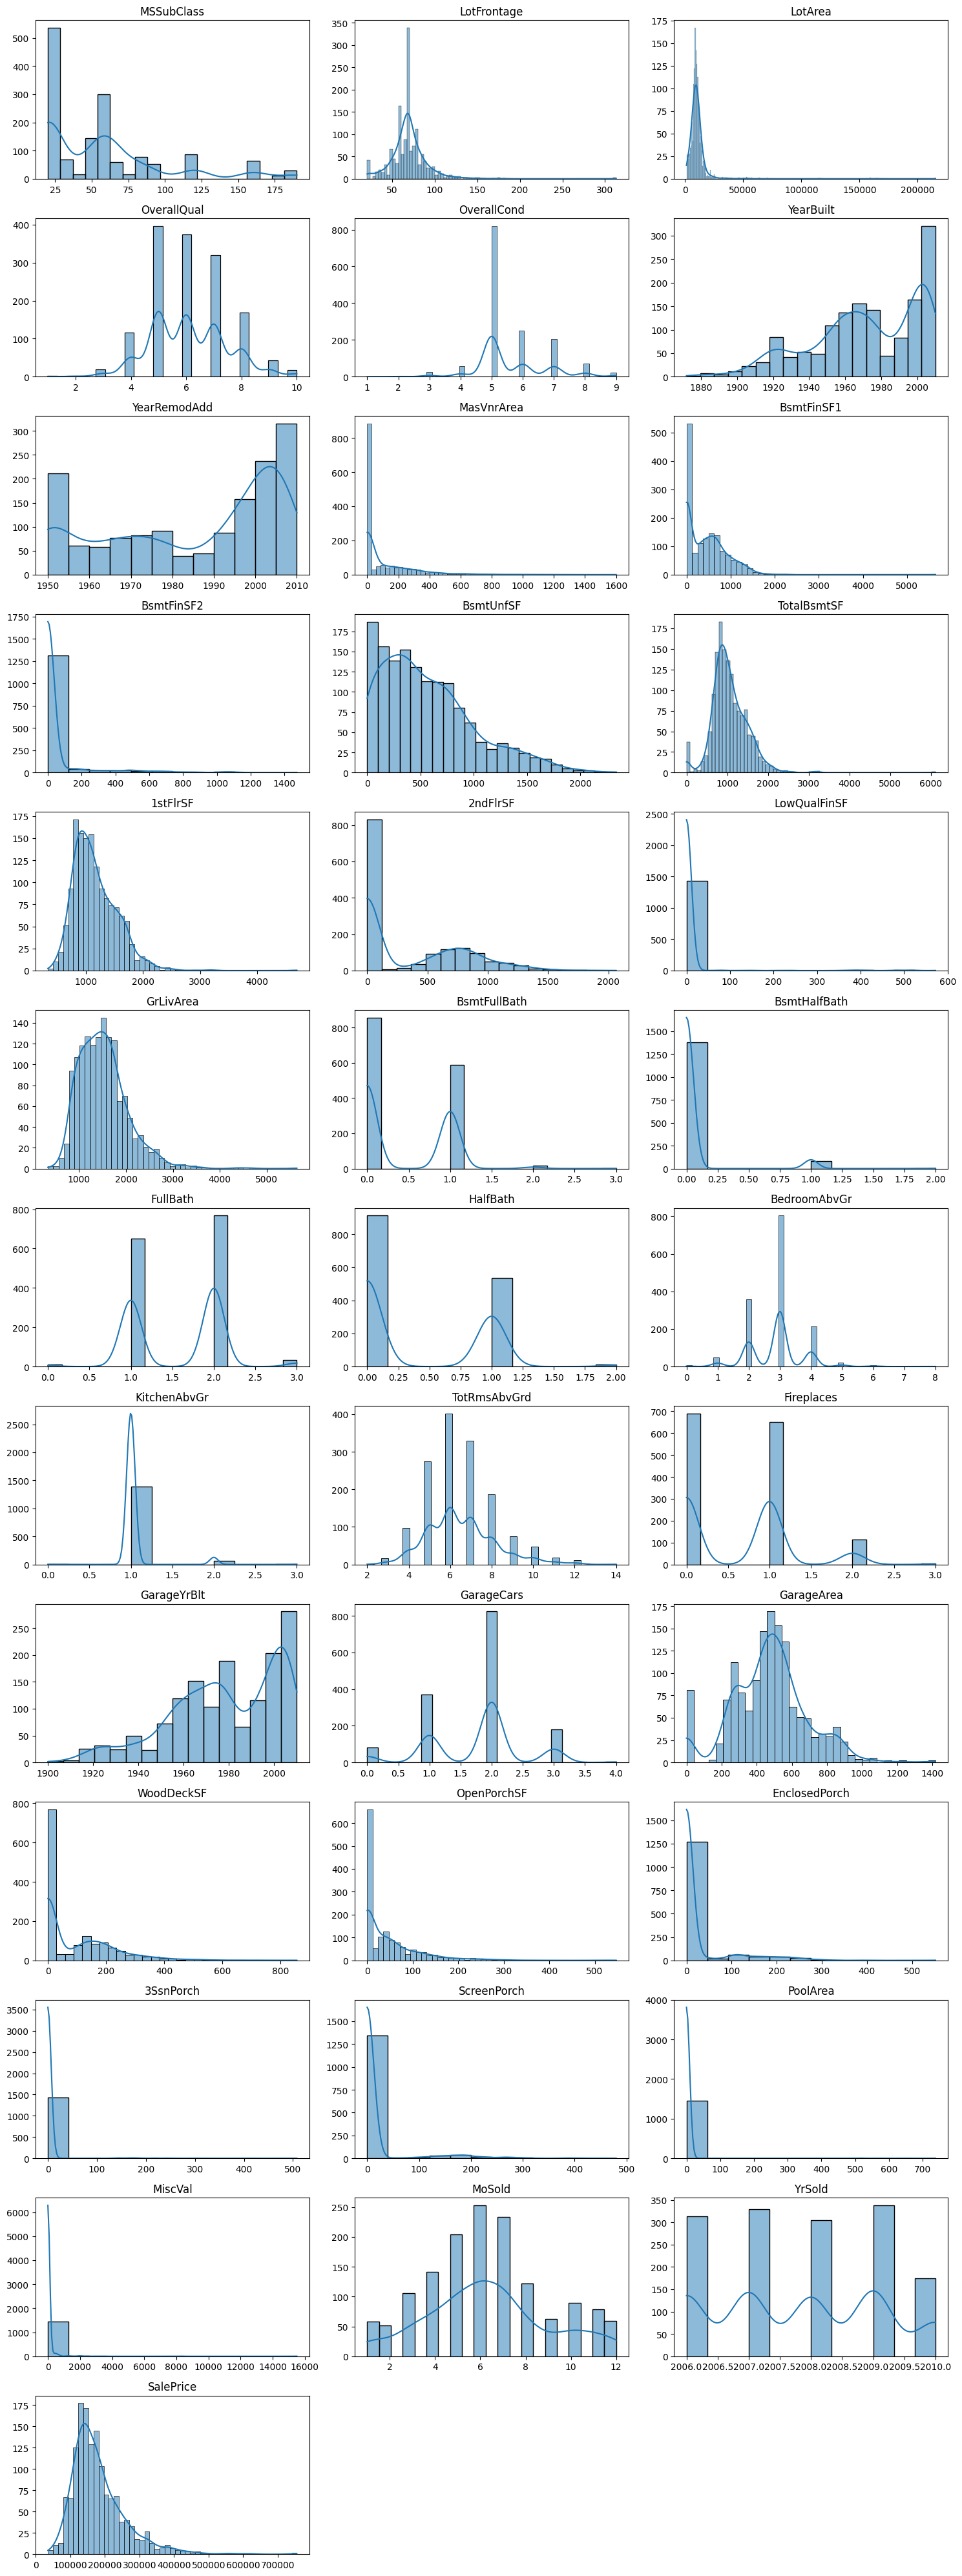

In [199]:
#Visualizing the distribution of the numerical features in the train set with histograms+KDE using subplots
fig, axes = plt.subplots(nrows=13, ncols=3, figsize=(15, 40))
axes = axes.flatten()
for i, col in enumerate(num_trainset_df.columns):
    sns.histplot(num_trainset_df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    #Deleting the last empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [200]:
#Checking the skewness of the numerical features in the trainset
skewness = num_trainset_df.skew().sort_values(ascending=False)
print("Skewness of numerical features in the trainset: \n", skewness)

Skewness of numerical features in the trainset: 
 MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677142
LotFrontage       2.412330
OpenPorchSF       2.364342
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearB

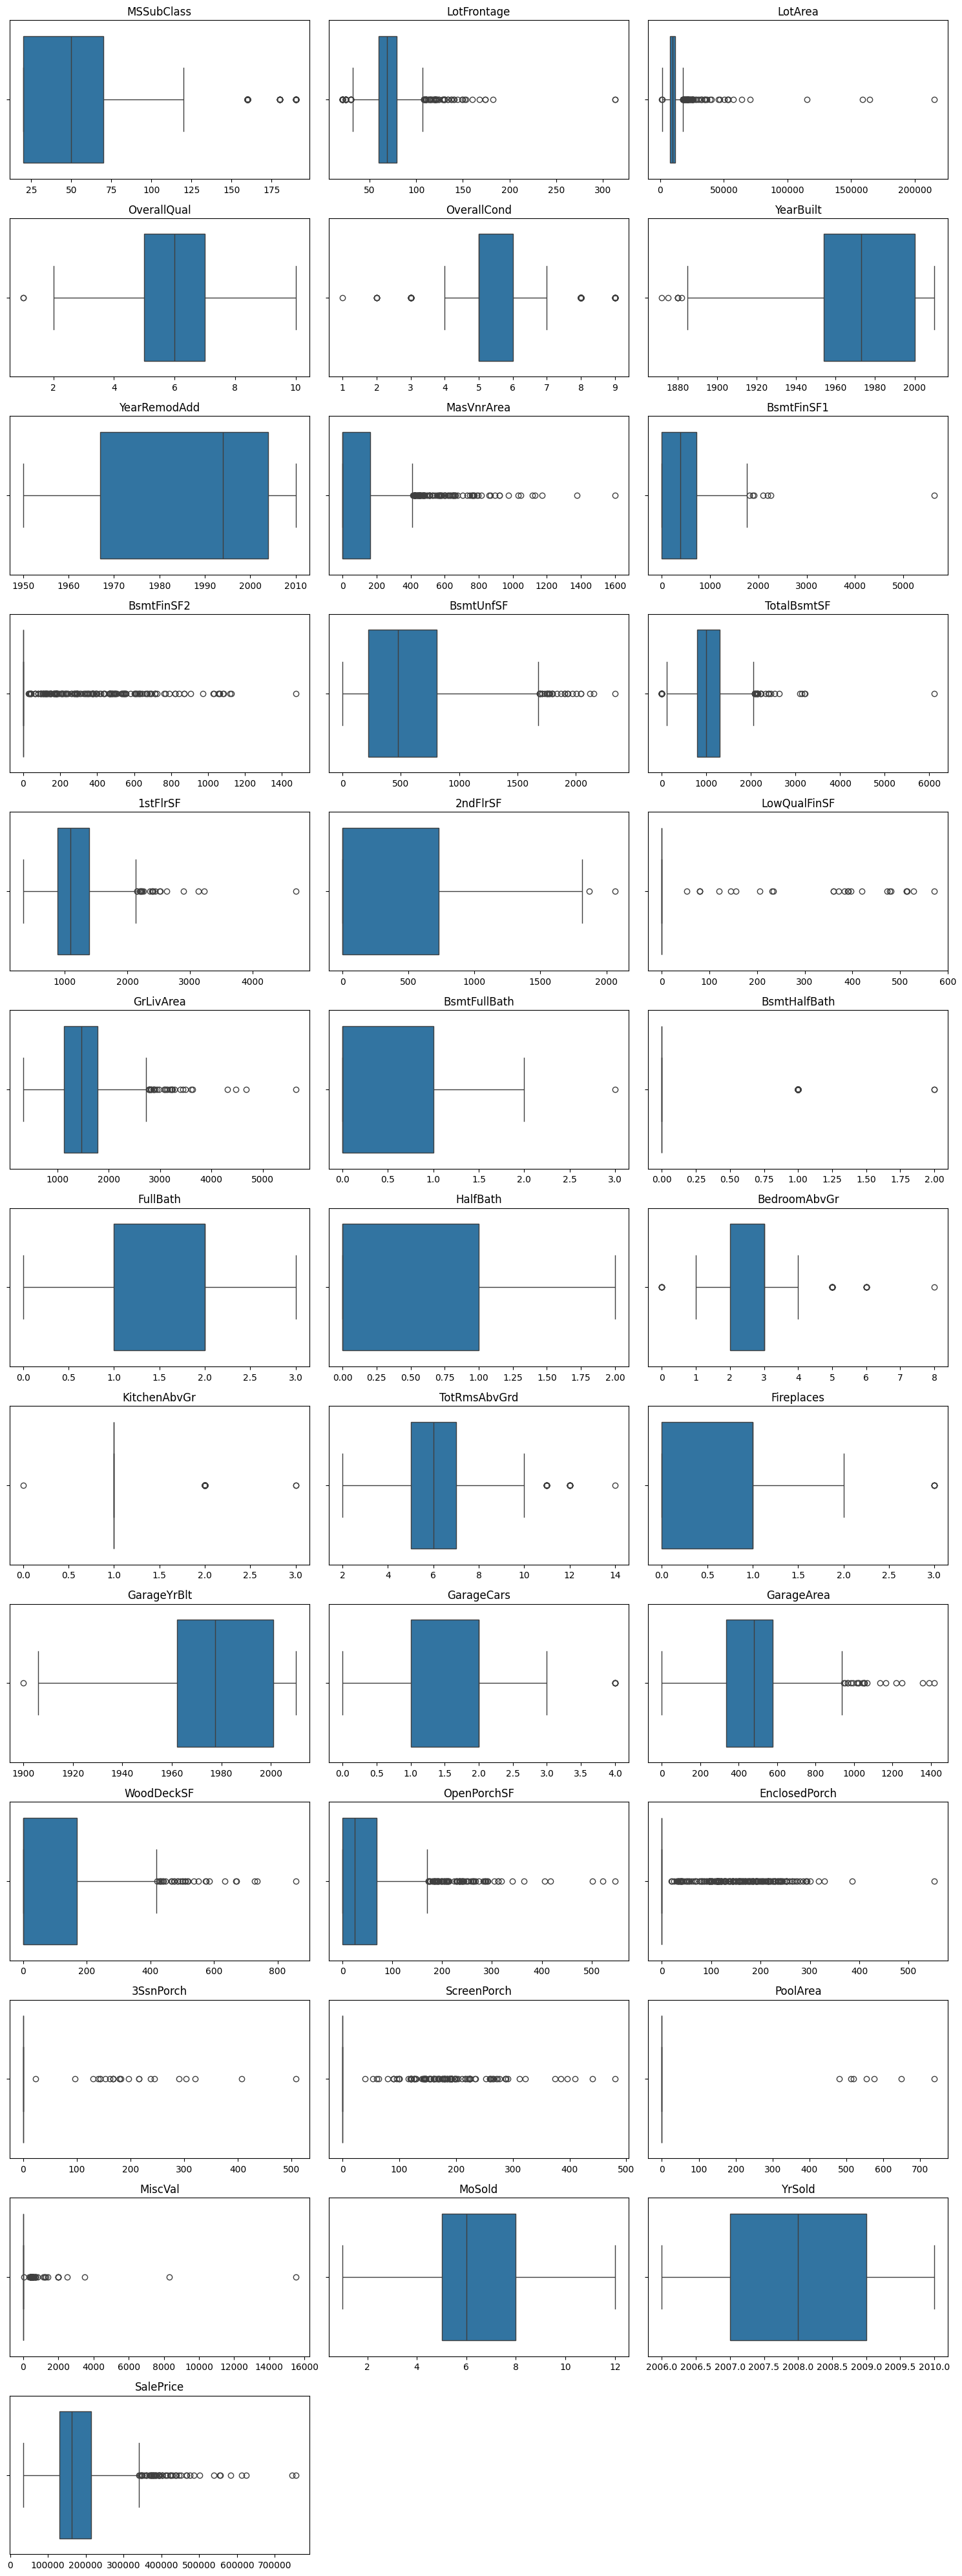

In [201]:
#Visualizing ouliers in the numerical features of the train set using boxplots
fig, axes = plt.subplots(nrows=13, ncols=3, figsize=(15, 40))
axes = axes.flatten()
for i, col in enumerate(num_trainset_df.columns):
    sns.boxplot(x=num_trainset_df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
#Deleting the last empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

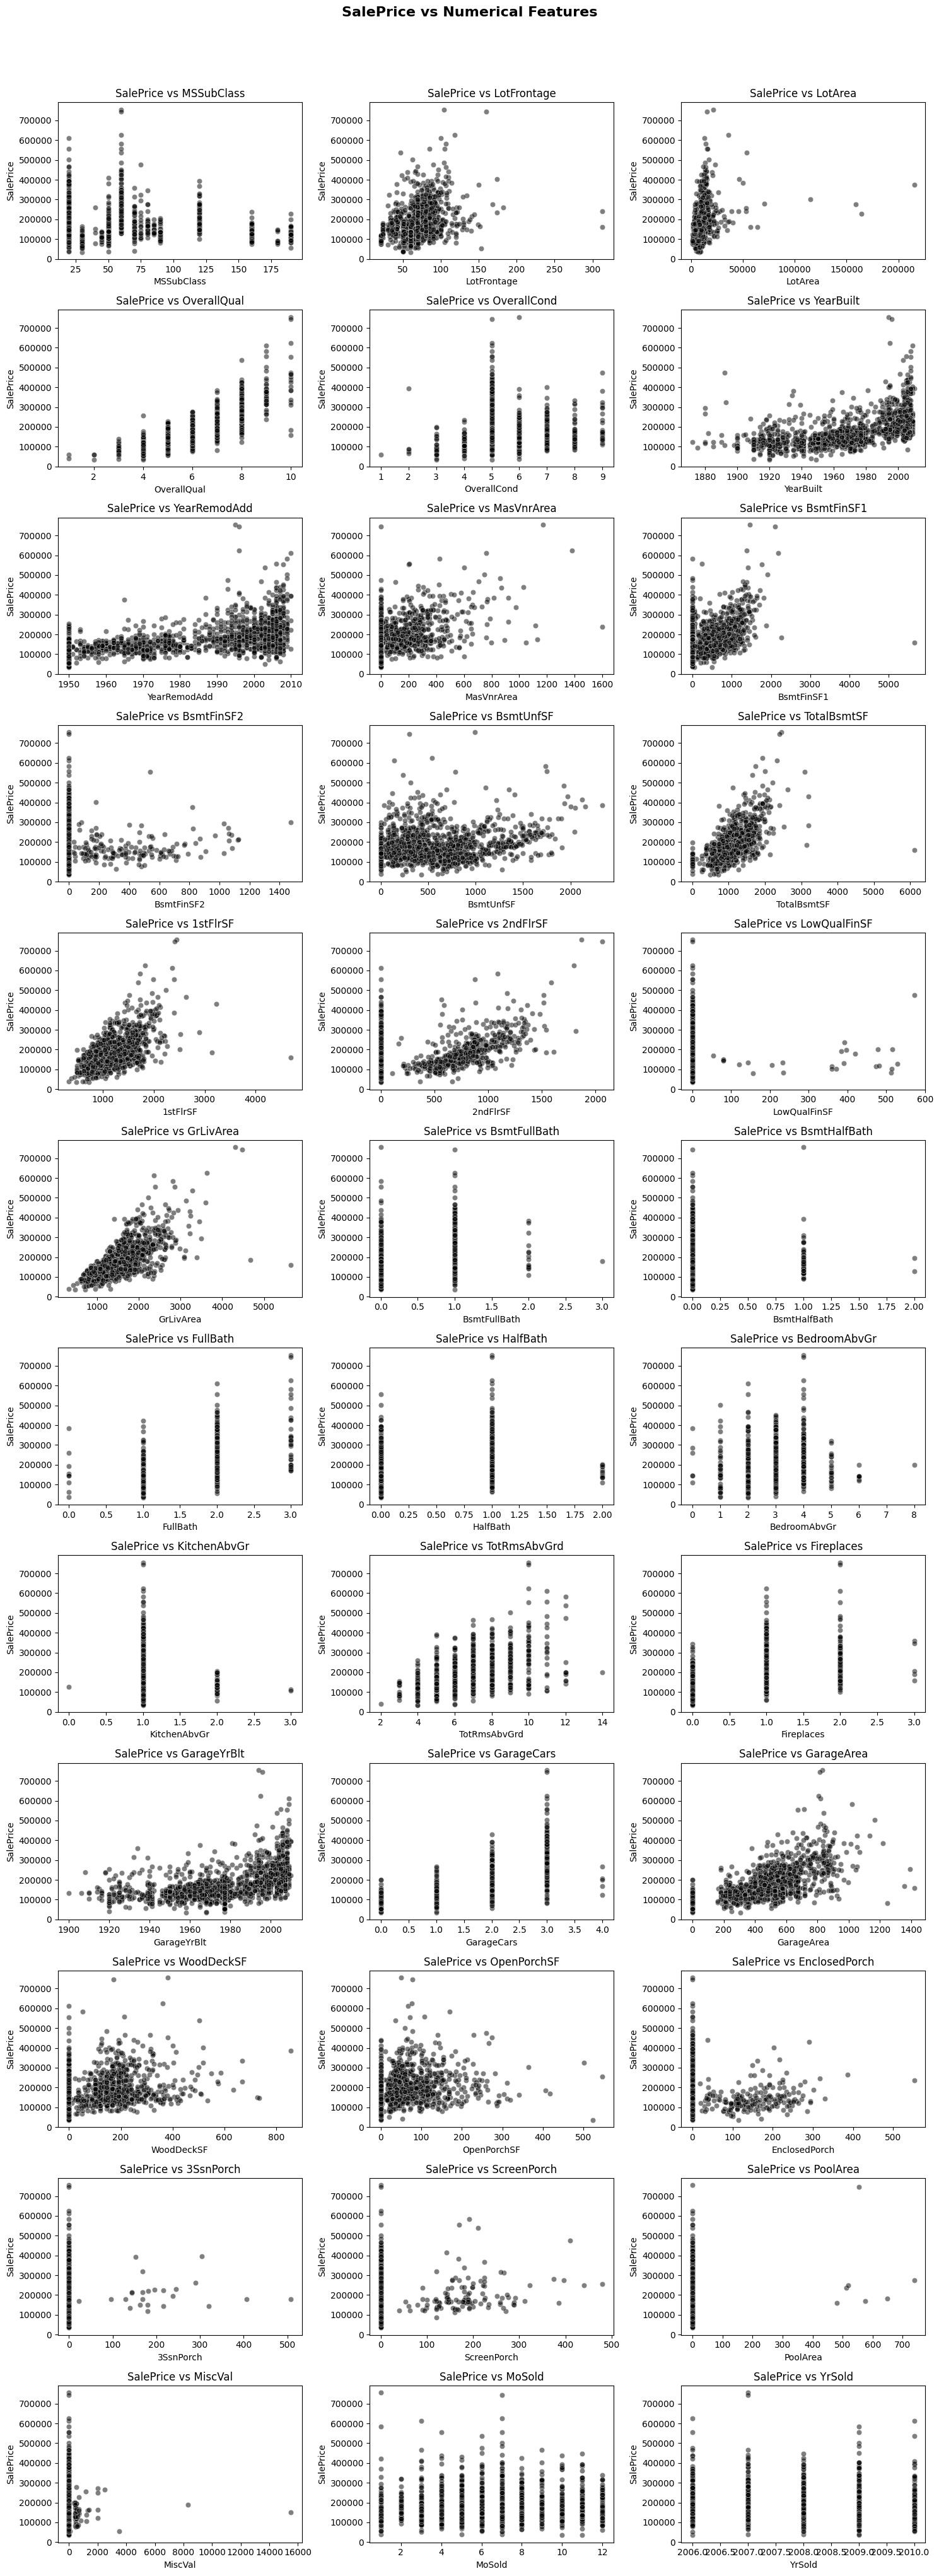

In [202]:
#Viewing the relationaship between the numerical features and the target variable 'SalePrice' using scatter plots
fig, axes = plt.subplots(nrows=12, ncols=3, figsize=(15, 40))
plt.suptitle('SalePrice vs Numerical Features', fontsize=16, fontweight='bold', y=1.02)
axes = axes.flatten()
for i, col in enumerate(num_trainset_df.drop(columns="SalePrice", axis=1).columns):
    sns.scatterplot(x=num_trainset_df[col], y=trainset_df['SalePrice'], ax=axes[i], color='black', alpha=0.5)
    axes[i].set_title(f'SalePrice vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
plt.tight_layout()
plt.show()

In [203]:
cat_trainset_df.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

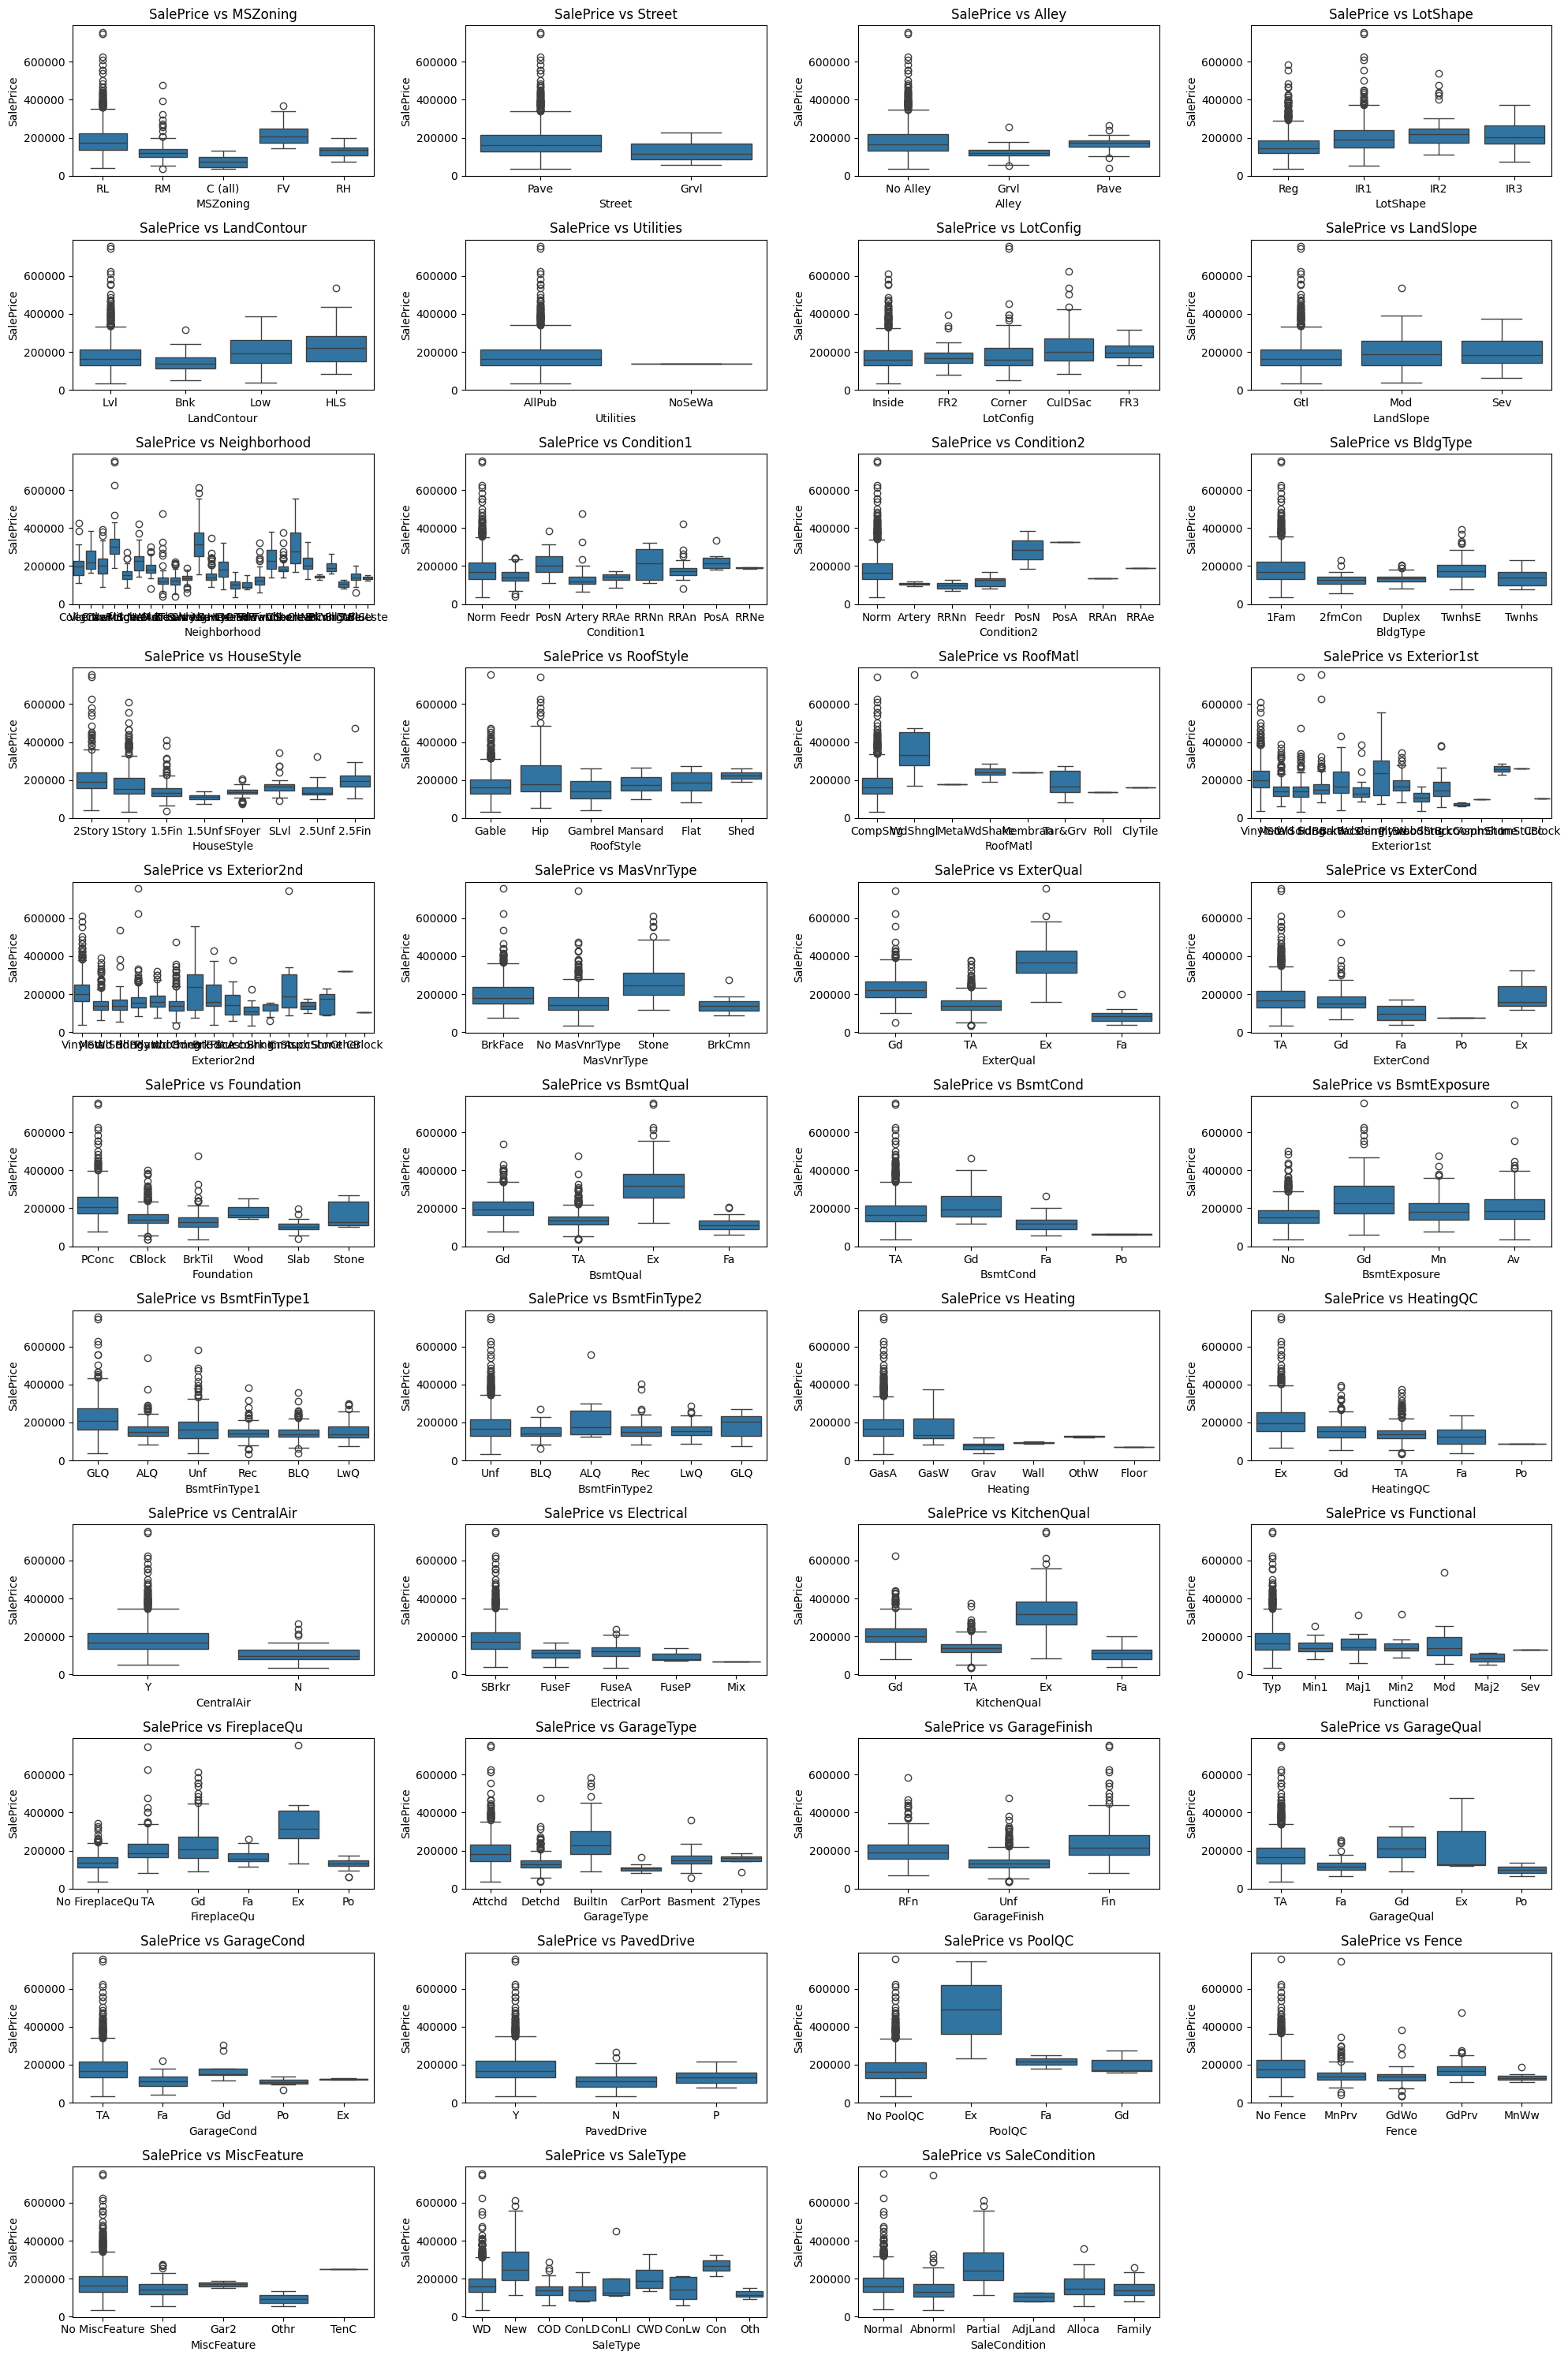

In [204]:
#Viewing the relationship between the categorical features and the target variable 'SalePrice' using boxplots
fig, axes = plt.subplots(nrows=11, ncols=4, figsize=(20, 30))
for i, col in enumerate(cat_trainset_df.columns):
    sns.boxplot(x=cat_trainset_df[col], y=trainset_df['SalePrice'], ax=axes[i // 4, i % 4])
    axes[i // 4, i % 4].set_title(f'SalePrice vs {col}')
    axes[i // 4, i % 4].set_xlabel(col)
    axes[i // 4, i % 4].set_ylabel('SalePrice')
#Deleting the last empty subplots
for j in range(i + 1, len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])
plt.tight_layout()
plt.show()

## ii. EDA  on Testset

In [205]:
#Creating separate DataFrames for numerical and categorical columns in the testset
num_testset_df = testset_df.drop(columns=['Id'], axis=1).select_dtypes(include=['int64', 'float64'])
cat_testset_df = testset_df.select_dtypes(include=['object'])

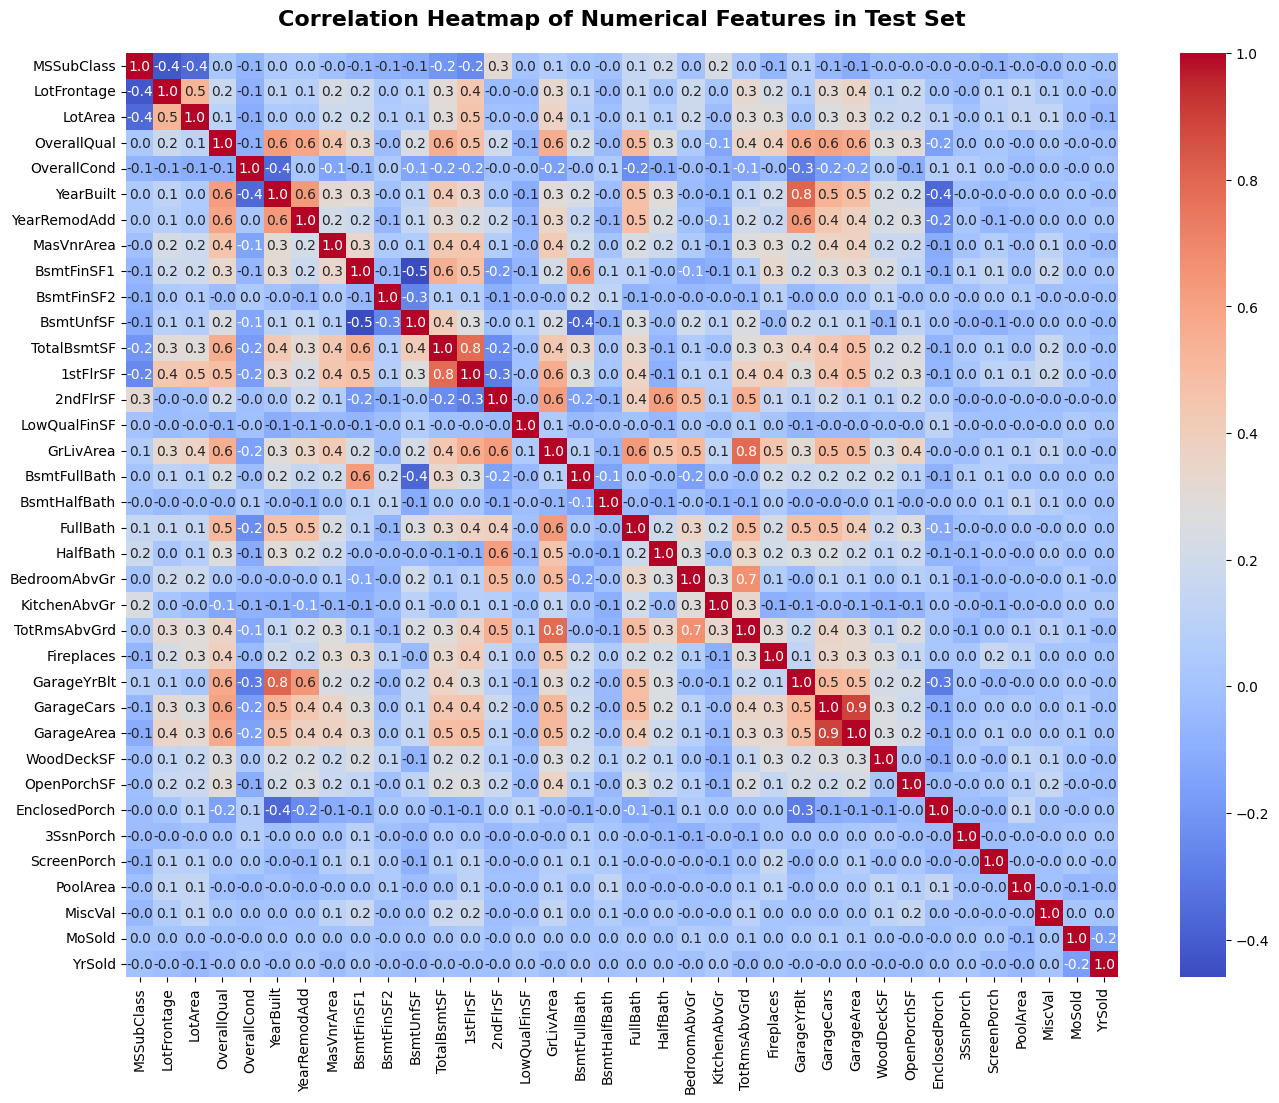

In [206]:
#Visualizing the correlation heatmap of numerical features in the testset
plt.figure(figsize=(16, 12))
sns.heatmap(data = num_testset_df.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features in Test Set', fontsize=16, pad=20, fontweight='bold')
plt.show()

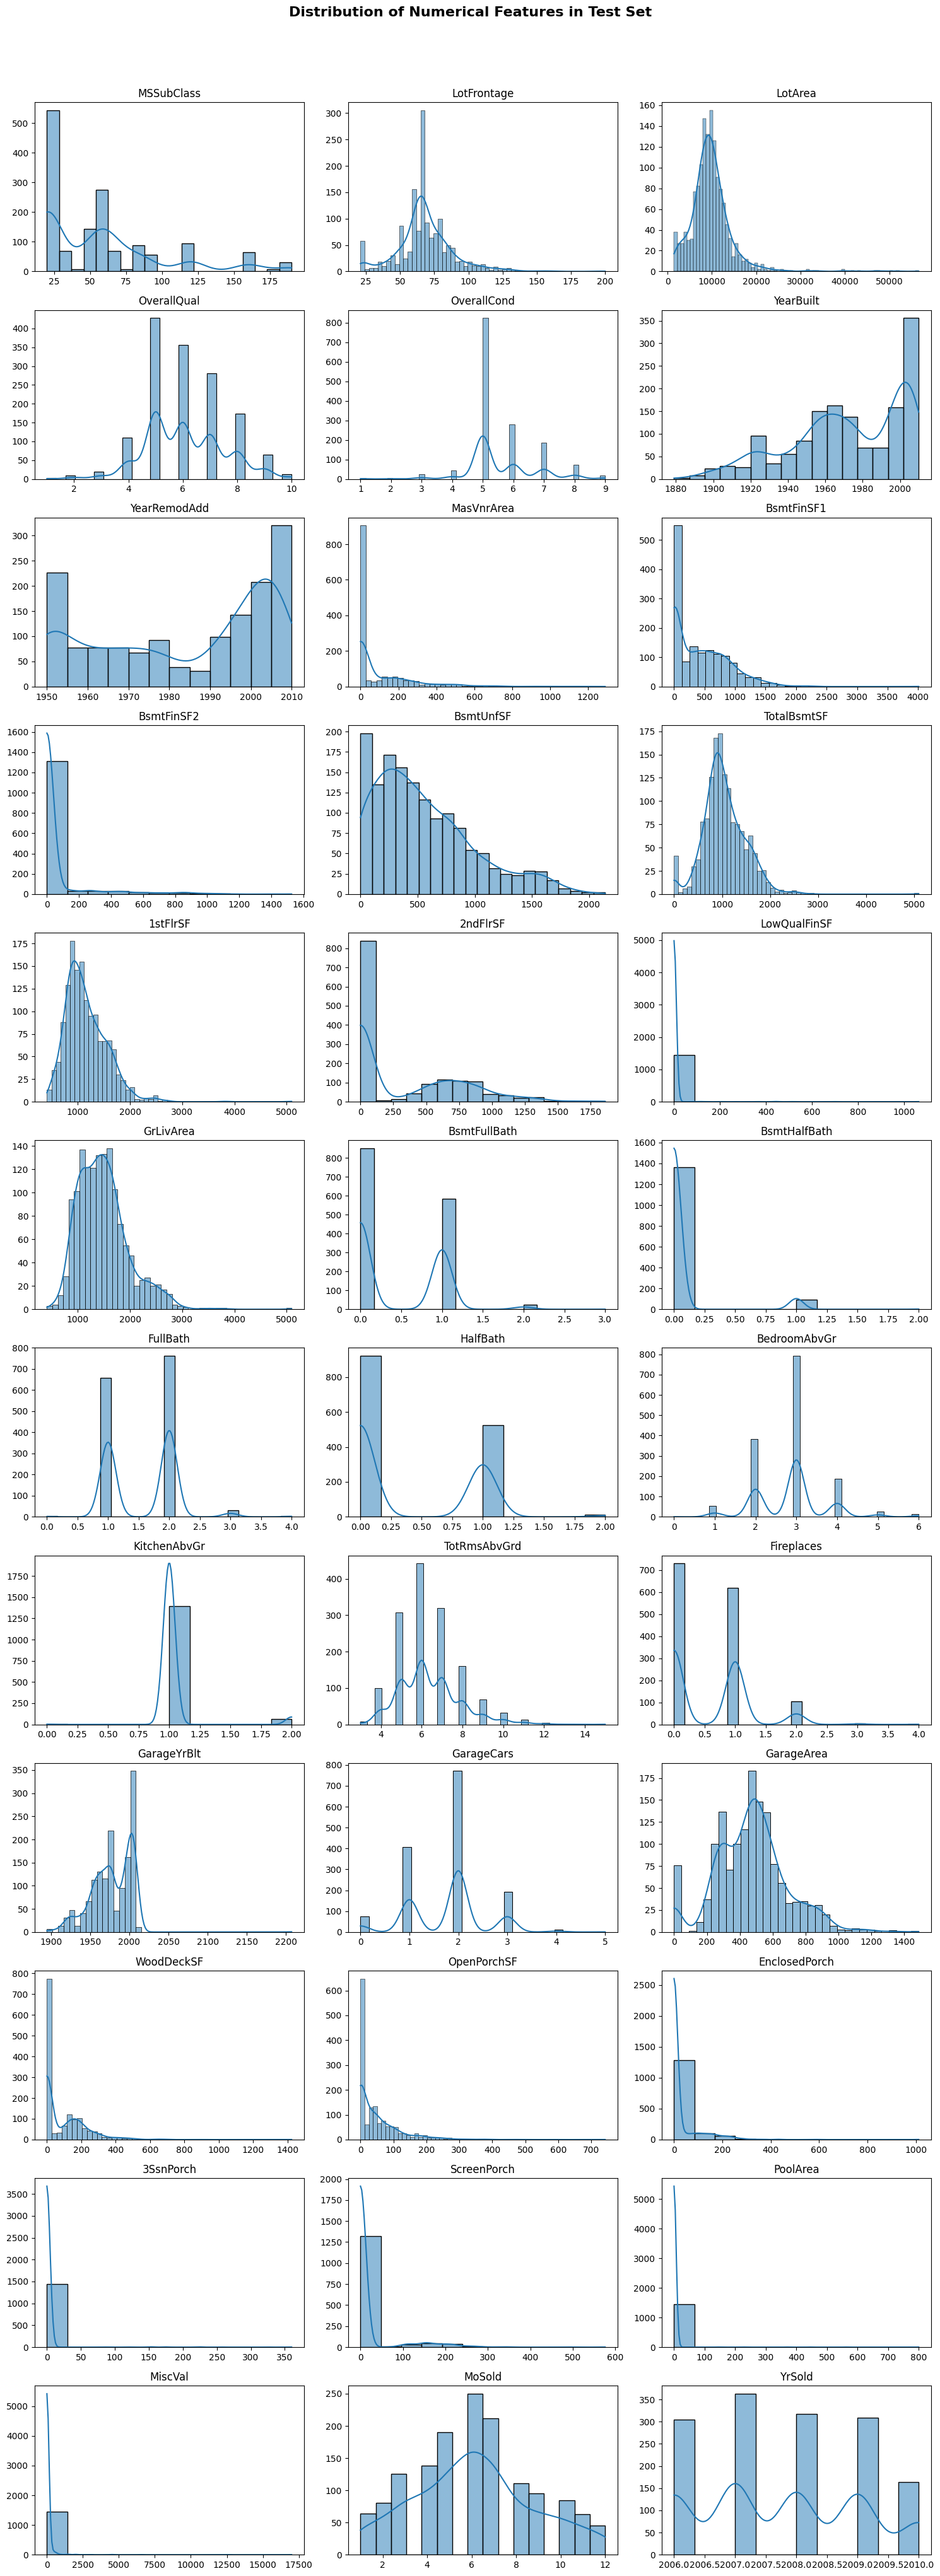

In [207]:
#Visualizing the distribution of the numerical features in the testset with histograms+KDE using subplots
fig, axes = plt.subplots(nrows=12, ncols=3, figsize=(15, 40))
plt.suptitle('Distribution of Numerical Features in Test Set', fontsize=16, fontweight='bold', y=1.02) 
axes = axes.flatten()
for i, col in enumerate(num_testset_df.columns):
    sns.histplot(num_testset_df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
#Deleting the last empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [208]:
#Viewing the skewness of the numerical features in the testset
skewness_test = num_testset_df.skew().sort_values(ascending=False)
print("Skewness of numerical features in the testset: \n", skewness_test)

Skewness of numerical features in the testset: 
 PoolArea         20.196888
MiscVal          20.075188
LowQualFinSF     16.167254
3SsnPorch        12.524216
EnclosedPorch     4.669172
KitchenAbvGr      4.079055
BsmtFinSF2        4.042954
ScreenPorch       3.788244
BsmtHalfBath      3.782976
LotArea           3.115217
OpenPorchSF       2.687779
MasVnrArea        2.545945
WoodDeckSF        2.130760
1stFlrSF          1.558195
MSSubClass        1.346690
BsmtFinSF1        1.166603
GrLivArea         1.130402
BsmtUnfSF         0.920779
2ndFlrSF          0.912883
TotRmsAbvGrd      0.842597
Fireplaces        0.819858
TotalBsmtSF       0.814339
LotFrontage       0.769239
HalfBath          0.714728
BsmtFullBath      0.651865
OverallCond       0.449165
BedroomAbvGr      0.436623
GarageArea        0.300273
FullBath          0.295839
MoSold            0.183022
OverallQual       0.181196
YrSold            0.168986
GarageCars       -0.107770
GarageYrBlt      -0.150534
YearRemodAdd     -0.399906
YearBu

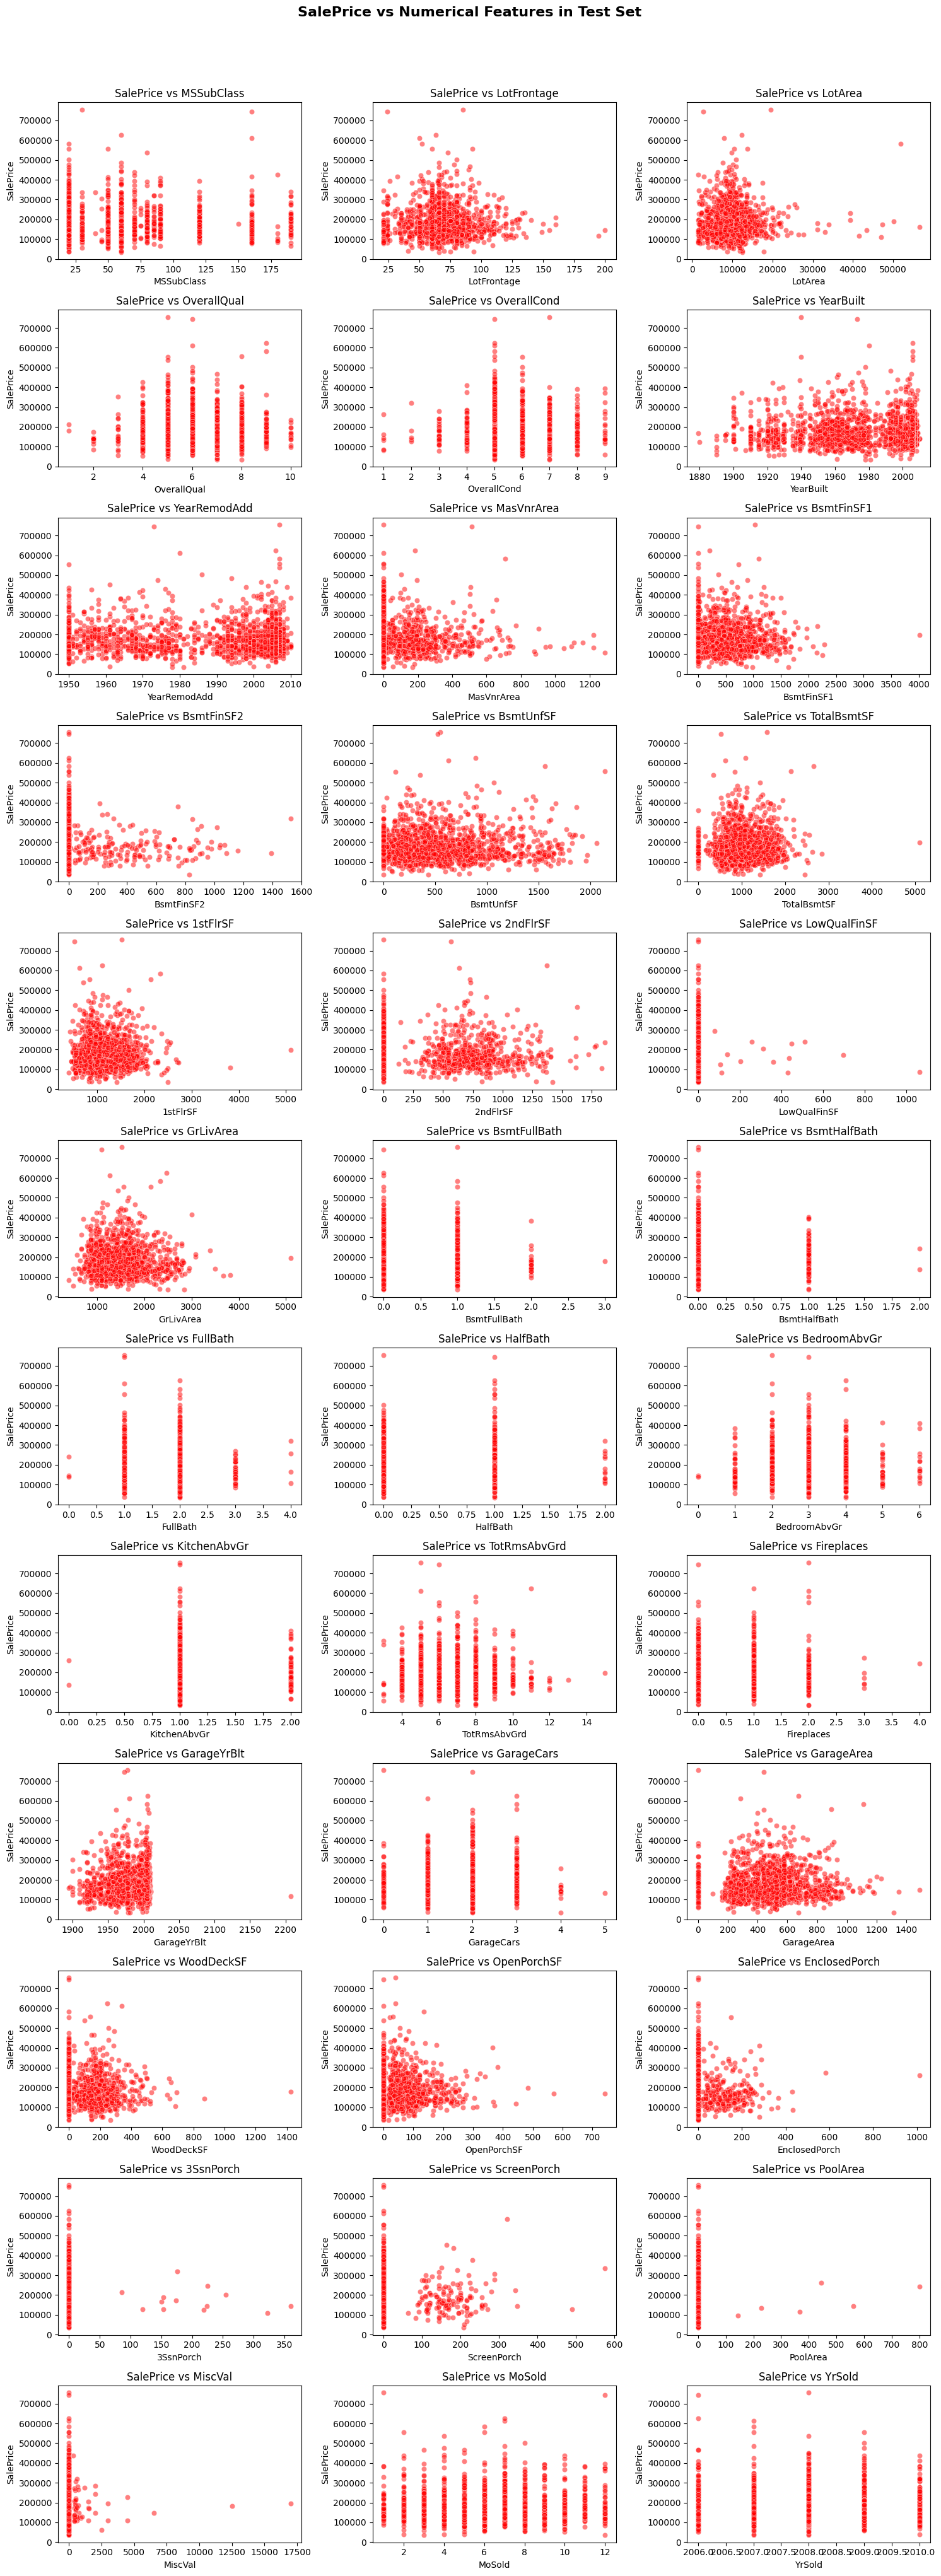

In [209]:
#Viewing the relationship between the target variable "SalePrice" and the numerical features in the testset using scatter plots
fig, axes = plt.subplots(nrows=12, ncols=3, figsize=(15, 40))
plt.suptitle('SalePrice vs Numerical Features in Test Set', fontsize=16, fontweight='bold', y=1.02)
axes = axes.flatten()
for i, col in enumerate(num_testset_df.columns):
    sns.scatterplot(x=num_testset_df[col], y=trainset_df['SalePrice'], ax=axes[i], color='red', alpha=0.5)
    axes[i].set_title(f'SalePrice vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
plt.tight_layout()
plt.show()

In [210]:
cat_testset_df.shape

(1459, 43)

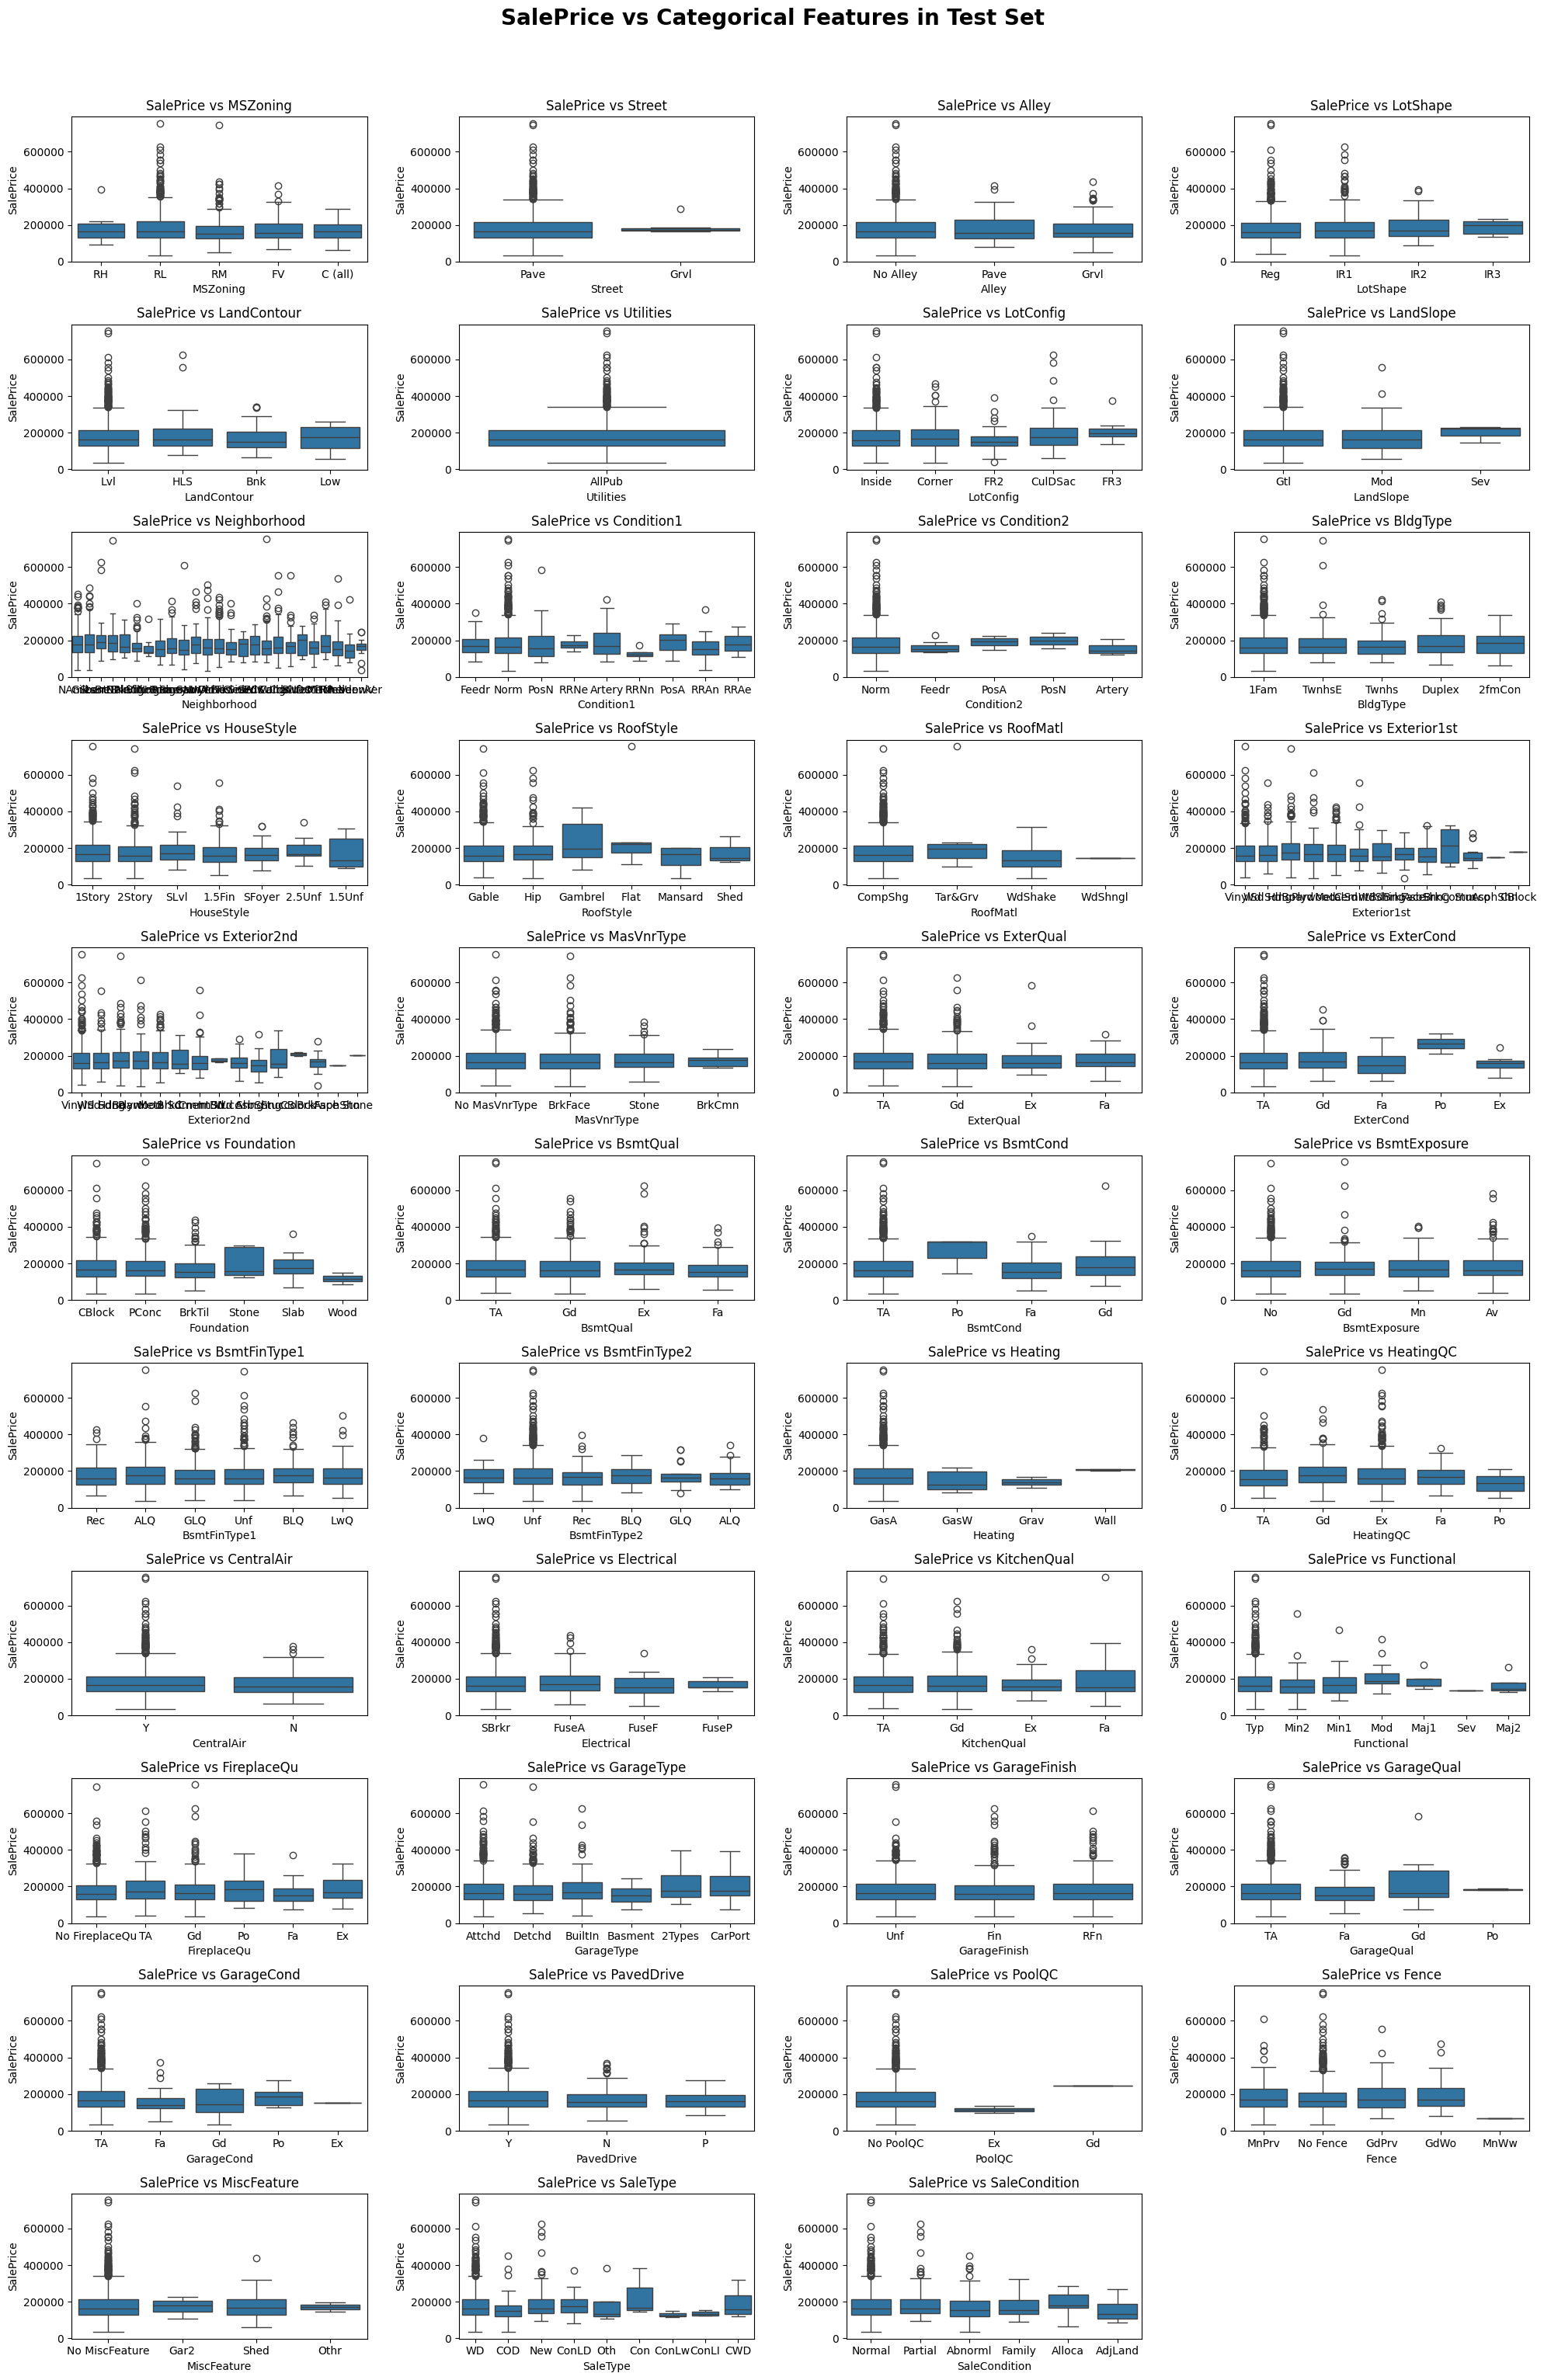

In [211]:
#Visualizing the relationship between the testset categorical features and the target variable 'SalePrice' using boxplots
fig, axes = plt.subplots(nrows=11, ncols=4, figsize=(20, 30))
plt.suptitle('SalePrice vs Categorical Features in Test Set', fontsize=20, fontweight='bold', y=1.02)
for i, col in enumerate(cat_testset_df.columns):
    sns.boxplot(x=cat_testset_df[col], y=trainset_df['SalePrice'], ax=axes[i // 4, i % 4])
    axes[i // 4, i % 4].set_title(f'SalePrice vs {col}')
    axes[i // 4, i % 4].set_xlabel(col)
    axes[i // 4, i % 4].set_ylabel('SalePrice')
#Deleting the last empty subplots
for j in range(i + 1, len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])
plt.tight_layout()
plt.show()

## iii. Random EDA

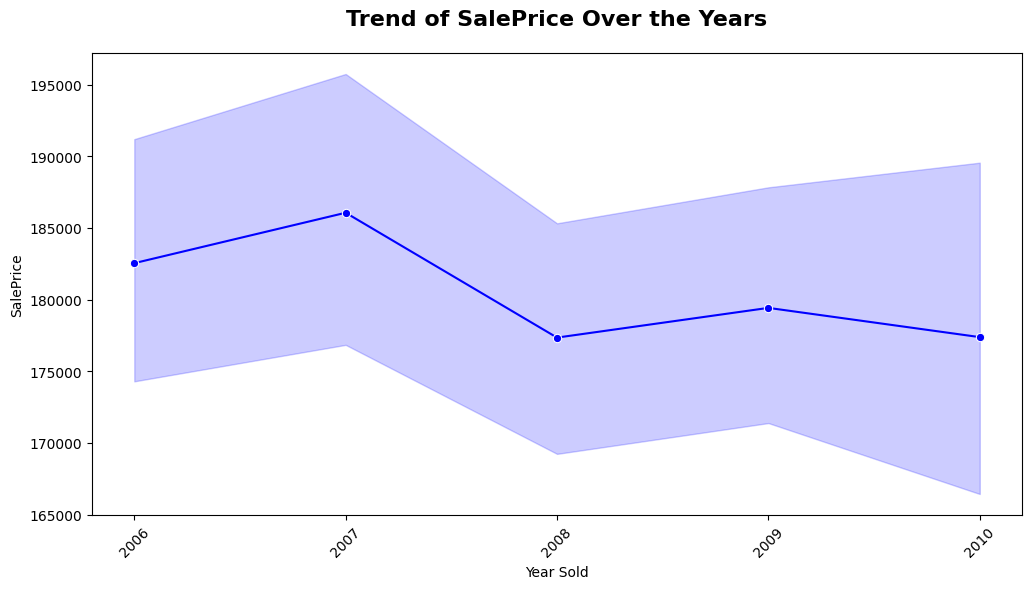

In [212]:
#Visualizing the trend of the SalePrice over the years using a line plot
import matplotlib.ticker as ticker
plt.figure(figsize=(12, 6))
sns.lineplot(x=trainset_df['YrSold'], y=trainset_df['SalePrice'], marker='o', color='blue')
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('Trend of SalePrice Over the Years', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year Sold')
plt.ylabel('SalePrice')
plt.xticks(rotation=45)
plt.show()

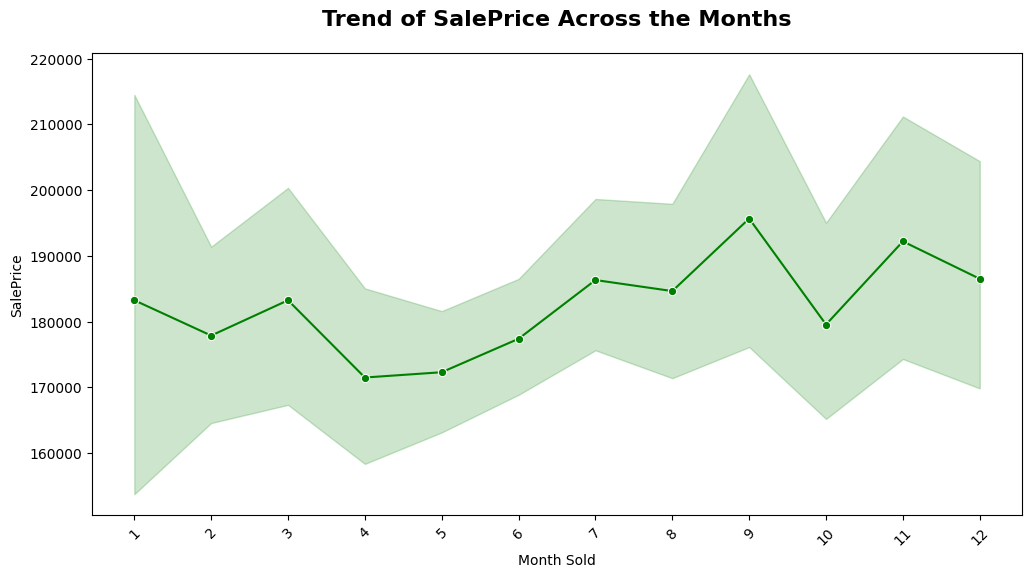

In [213]:
#Visualoizing the trend of SalePrice across the months using a line plot
from matplotlib.ticker import MultipleLocator
plt.figure(figsize=(12, 6))
sns.lineplot(x=trainset_df['MoSold'], y=trainset_df['SalePrice'], marker='o', color='green')
plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.title('Trend of SalePrice Across the Months', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month Sold')
plt.ylabel('SalePrice')
plt.xticks(rotation=45)
plt.show()

In [214]:
#Viewing the distribution of 'YrSold' in the testset
testset_df['YrSold'].value_counts().sort_index()

YrSold
2006    305
2007    363
2008    318
2009    309
2010    164
Name: count, dtype: int64

In [215]:
#Viewing the correlation between 'YrSold' and 'SalePrice' in the trainset
trainset_df['YrSold'].corr(trainset_df['SalePrice'])

np.float64(-0.028922585168730357)

In [216]:
#Viewing the correlation between 'MoSold' and 'SalePrice' in the trainset
trainset_df['MoSold'].corr(trainset_df['SalePrice'])

np.float64(0.04643224522381938)

# 4. FEATURE ENGINEERING

In [217]:
#Creating "Remod" feature in the train and test sets
# Train set 
trainset_df['NoYearsRemod'] = trainset_df['YearRemodAdd'] - trainset_df['YearBuilt']
trainset_df["Remod"] = trainset_df["NoYearsRemod"].apply(lambda x: 1 if x > 0 else 0)
# Test set
testset_df['NoYearsRemod'] = testset_df['YearRemodAdd'] - testset_df['YearBuilt']
testset_df["Remod"] = testset_df["NoYearsRemod"].apply(lambda x: 1 if x > 0 else 0)

In [218]:
#Creating a new feature of "AgeSinceRemod" in both train and test sets
trainset_df['AgeSinceRemod'] = trainset_df['YrSold'] - trainset_df['YearRemodAdd']

testset_df['AgeSinceRemod'] = testset_df['YrSold'] - testset_df['YearRemodAdd']

In [219]:
#Creating a new feature of "AgeAtSale" in both datasets
trainset_df['AgeAtSale'] = trainset_df['YrSold'] - trainset_df['YearBuilt']
testset_df['AgeAtSale'] = testset_df['YrSold'] - testset_df['YearBuilt']

In [220]:
#Creating a new feature of "seasonSold" in both datasets
def month_to_season(month):
    if month in [12,1,2]: return "Winter"
    elif month in [3,4,5]: return "Spring"
    elif month in [6,7,8]: return "Summer"
    else: return "Fall"

trainset_df['SeasonSold'] = trainset_df['MoSold'].apply(month_to_season)
testset_df['SeasonSold'] = testset_df['MoSold'].apply(month_to_season)


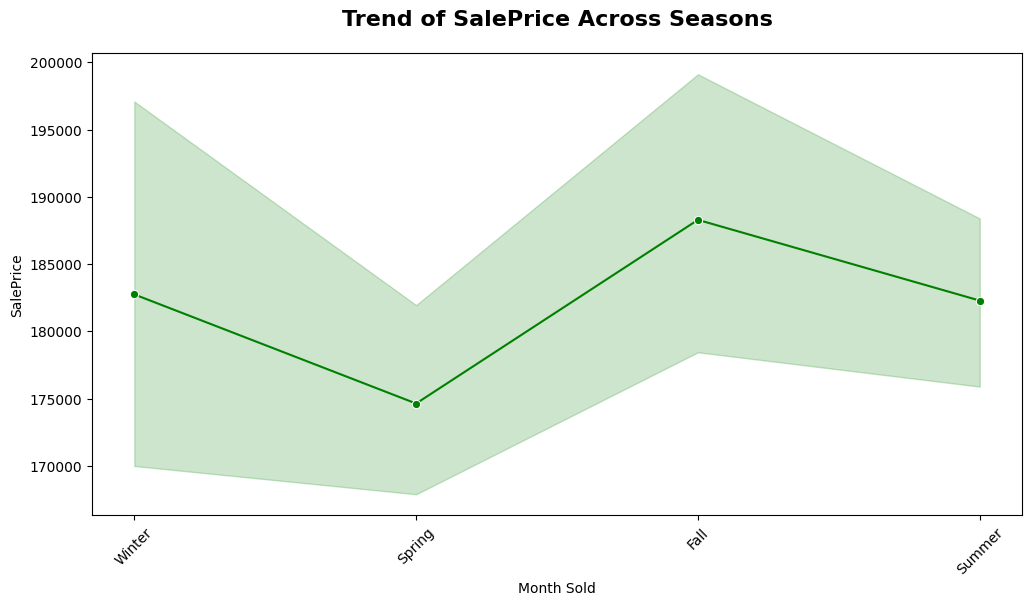

In [221]:
#Visualoizing the trend of SalePrice across seasons using a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=trainset_df['SeasonSold'], y=trainset_df['SalePrice'], marker='o', color='green')
#plt.gca().xaxis.set_major_locator(MultipleLocator(1))
plt.title('Trend of SalePrice Across Seasons', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month Sold')
plt.ylabel('SalePrice')
plt.xticks(rotation=45)
plt.show()

In [222]:
#Creating a new feature of "MarketTrend" in both datasets
year_price_map = trainset_df.groupby("YrSold")["SalePrice"].mean().to_dict()
trainset_df['MarketTrend'] = trainset_df['YrSold'].map(year_price_map)
testset_df['MarketTrend'] = testset_df['YrSold'].map(year_price_map)

In [223]:
trainset_df['MarketTrend'].corr(trainset_df['SalePrice'])

np.float64(0.04208914368306473)

In [224]:
#Viewing the correlation between 'Remod' and 'SalePrice' in the trainset
trainset_df['Remod'].corr(trainset_df['SalePrice'])

np.float64(-0.021932600051564548)

Notes:
* NoYearsRemod = YearRemodAdd - YearsBuilt
* Remod = True (if NoYearsRemod > 0), False (if NoYearsRemod = 0)
* SeasonSold = Apply month_to_season function to MoSold
* AgeAtSale = YrSold - YearBuilt
* AgeSinceRemod = YrSold - YearRemodAdd





In [225]:
trainset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 87 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [226]:
testset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 86 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   object 
 3   LotFrontage    1459 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          1459 non-null   object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1459 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [227]:
#Creating new separate DataFrames for numerical and categorical columns in the trainset
new_num_trainset_df = trainset_df.drop(columns=['Id'], axis=1).select_dtypes(include=['int64', 'float64'])
new_cat_trainset_df = trainset_df.select_dtypes(include=['object'])

In [228]:
#Checking the skewness of the new numerical features in the trainset
new_skewness = new_num_trainset_df.skew().sort_values(ascending=False)
print("Skewness of new numerical features in the trainset: \n", new_skewness)

Skewness of new numerical features in the trainset: 
 MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677142
LotFrontage       2.412330
OpenPorchSF       2.364342
NoYearsRemod      1.957396
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
AgeAtSale         0.609030
BsmtFullBath      0.596067
AgeSinceRemod     0.502489
MarketTrend       0.432672
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
Y

In [229]:
#Viewing the correlation of new numerical features with 'SalePrice' in the trainset
train_correlation_with_saleprice = new_num_trainset_df.corr()['SalePrice'].sort_values(ascending=False)
print("Correlation of features with 'SalePrice' in the trainset: \n", train_correlation_with_saleprice)

Correlation of features with 'SalePrice' in the trainset: 
 SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.477264
MasVnrArea       0.474284
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334740
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
MarketTrend      0.042089
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Remod           -0.021933
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSu

In [230]:
cols_to_drop = ['KitchenAbvGr', 'OverallCond', 'MSSubClass', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 
                'LowQualFinSF', 'BsmtFinSF2', 'BsmtHalfBath', 'Remod', 'NoYearsRemod', 'YrSold', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']

In [257]:
#Dropping less important features from both datasets
trainset = trainset_df.drop(columns=cols_to_drop, axis=1)
testset = testset_df.drop(columns=cols_to_drop, axis=1)

# 4. FEATURE ENCODING

In [258]:
#Ordinal encoding mappings
ordinal_mappings = {
    "ExterQual": ["Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["NA", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["No FireplaceQu", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],
    "PoolQC": ["No PoolQC", "Fa", "TA", "Gd", "Ex"],
    "Fence": ["No Fence", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "PavedDrive": ["N", "P", "Y"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
    # HouseStyle ordering
    "HouseStyle": ["1Story","1.5Unf","1.5Fin","2Story","2.5Unf","2.5Fin","SFoyer","SLvl"]
}
ordinal_features = list(ordinal_mappings.keys())
ordinal_encoder = OrdinalEncoder(
    categories=[ordinal_mappings[feat] for feat in ordinal_features]
)


In [ ]:
#Nominal features to be one-hot encoded
nominal_features = [
    "MSZoning","Street","Alley","LotConfig","Neighborhood",
    "Condition1","Condition2","BldgType","RoofStyle","RoofMatl",
    "Exterior1st","Exterior2nd","MasVnrType","Foundation","Heating",
    "Electrical","GarageType","SaleType","SaleCondition"
]
nominal_encoder = OneHotEncoder(handle_unknown="ignore")

In [261]:
#Defining the preprocessing pipelines for numerical data
numeric_features = ['LotFrontage', 'LotArea', 'OverallQual', 'MasVnrArea',
                    'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
                    'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
                    'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF',
                    'OpenPorchSF', 'AgeSinceRemod', 'AgeAtSale',
                    'MarketTrend']
numeric_transformer = SimpleImputer(strategy='constant')

In [262]:
#Combining all preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_encoder, ordinal_features),
        ("nom", nominal_encoder, nominal_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

# 5. MODEL DEVELOPMENT

In [263]:
#Splitting the trainset into features and target variable
X = trainset.drop(columns=['SalePrice', 'Id'], axis=1)
y = trainset['SalePrice']

In [264]:
#Splitting the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape, "X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape, "y_val shape:", y_val.shape)

X_train shape: (1168, 67) X_val shape: (292, 67)
y_train shape: (1168,) y_val shape: (292,)


In [265]:
testset = testset.drop(columns=['Id'], axis=1)
print("Testset shape:", testset.shape)

Testset shape: (1459, 67)


In [266]:
#Defining various regression models with pipelines
models = {
    "LinearRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", Lasso(alpha=0.001))
    ]),
    "RandomForest": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(n_estimators=300, random_state=42))
    ]),
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(n_estimators=500, learning_rate=0.05,
                                   max_depth=6, random_state=42))
    ]),
    "LightGBM": Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                    max_depth=-1, random_state=42))
    ])
}

In [267]:
#Evaluate each model
for name, pipeline in models.items():
     pipeline.fit(X_train, y_train)
     y_pred = pipeline.predict(X_val)
    
     mse = metrics.mean_squared_error(y_val, y_pred)
     mae = metrics.mean_absolute_error(y_val, y_pred)
     r2 = metrics.r2_score(y_val, y_pred)
    
     print('='*25, name, '='*25)
     print(f"   {name} MSE  = {mse:.4f}")
     print(f"   {name} RMSE = {np.sqrt(mse):.4f}")
     print(f"   {name} MAE  = {mae:.4f}")
     print(f"   {name} R²   = {r2:.4f}\n")

========================= LinearRegression =========================
   LinearRegression MSE  = 902810197.0428
   LinearRegression RMSE = 30046.8001
   LinearRegression MAE  = 19580.3540
   LinearRegression R²   = 0.8823

========================= Ridge =========================
   Ridge MSE  = 924974266.7421
   Ridge RMSE = 30413.3896
   Ridge MAE  = 19343.5303
   Ridge R²   = 0.8794



c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.978e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


========================= Lasso =========================
   Lasso MSE  = 866955414.1859
   Lasso RMSE = 29444.1066
   Lasso MAE  = 19274.7750
   Lasso R²   = 0.8870

========================= RandomForest =========================
   RandomForest MSE  = 795301015.1338
   RandomForest RMSE = 28201.0818
   RandomForest MAE  = 17170.5782
   RandomForest R²   = 0.8963

========================= XGBoost =========================
   XGBoost MSE  = 611030080.0000
   XGBoost RMSE = 24719.0226
   XGBoost MAE  = 16042.2998
   XGBoost R²   = 0.9203

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001913 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2890
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 116
[LightGBM] [Info] Start training from score 181441.541952
========================= LightGBM ========

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [268]:
#Hyperparameter tuning for Ridge Regression using GridSearchCV
ridge_params = {"model__alpha": [0.1, 1.0, 10.0, 100.0]}
ridge_search = GridSearchCV(Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
]), ridge_params, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_search.fit(X_train, y_train)
print("Best Ridge parameters:", ridge_search.best_params_)
print("Best Ridge RMSE:", -ridge_search.best_score_)

Best Ridge parameters: {'model__alpha': 100.0}
Best Ridge RMSE: 34266.23973426047


In [269]:
#Fitting the best Ridge model
best_ridge = ridge_search.best_estimator_
best_ridge.fit(X_train, y_train)
#Predicting on the validation set
y_val_pred_ridge = best_ridge.predict(X_val)
#Evaluating the Ridge model
ridge_mse = metrics.mean_squared_error(y_val, y_val_pred_ridge)
ridge_mae = metrics.mean_absolute_error(y_val, y_val_pred_ridge)
ridge_r2 = metrics.r2_score(y_val, y_val_pred_ridge)
print('='*25, "Tuned Ridge Regression", '='*25)
print(f"   Tuned Ridge MSE  = {ridge_mse:.4f}")
print(f"   Tuned Ridge RMSE = {np.sqrt(ridge_mse):.4f}")
print(f"   Tuned Ridge MAE  = {ridge_mae:.4f}")
print(f"   Tuned Ridge R²   = {ridge_r2:.4f}\n")




========================= Tuned Ridge Regression =========================
   Tuned Ridge MSE  = 1080771085.2104
   Tuned Ridge RMSE = 32875.0830
   Tuned Ridge MAE  = 19600.1345
   Tuned Ridge R²   = 0.8591



In [270]:
#Fitting the best LightGBM model
best_lgbm = models["LightGBM"]
best_lgbm.fit(X_train, y_train)
#Predicting on the validation set
y_val_pred_lgbm = best_lgbm.predict(X_val)
#Evaluating the LightGBM model
lgbm_mse = metrics.mean_squared_error(y_val, y_val_pred_lgbm)
lgbm_mae = metrics.mean_absolute_error(y_val, y_val_pred_lgbm)
lgbm_r2 = metrics.r2_score(y_val, y_val_pred_lgbm)
print('='*25, "LightGBM Regression", '='*25)
print(f"   LightGBM MSE  = {lgbm_mse:.4f}")
print(f"   LightGBM RMSE = {np.sqrt(lgbm_mse):.4f}")
print(f"   LightGBM MAE  = {lgbm_mae:.4f}")
print(f"   LightGBM R²   = {lgbm_r2:.4f}\n")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2890
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 116
[LightGBM] [Info] Start training from score 181441.541952
========================= LightGBM Regression =========================
   LightGBM MSE  = 852250387.3942
   LightGBM RMSE = 29193.3278
   LightGBM MAE  = 17046.4784
   LightGBM R²   = 0.8889



c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [271]:
#Fitting the best XGBoost model
best_xgb = models["XGBoost"]
best_xgb.fit(X_train, y_train)
#Predicting on the validation set
y_val_pred_xgb = best_xgb.predict(X_val)
#Evaluating the XGBoost model
xgb_mse = metrics.mean_squared_error(y_val, y_val_pred_xgb)
xgb_mae = metrics.mean_absolute_error(y_val, y_val_pred_xgb)
xgb_r2 = metrics.r2_score(y_val, y_val_pred_xgb)
print('='*25, "XGBoost Regression", '='*25)
print(f"   XGBoost MSE  = {xgb_mse:.4f}")
print(f"   XGBoost RMSE = {np.sqrt(xgb_mse):.4f}")
print(f"   XGBoost MAE  = {xgb_mae:.4f}")
print(f"   XGBoost R²   = {xgb_r2:.4f}\n")


========================= XGBoost Regression =========================
   XGBoost MSE  = 611030080.0000
   XGBoost RMSE = 24719.0226
   XGBoost MAE  = 16042.2998
   XGBoost R²   = 0.9203



In [272]:
#Fitting the best Linear Regression model
best_lr = models["LinearRegression"]
best_lr.fit(X_train, y_train)
#Predicting on the validation set
y_val_pred_lr = best_lr.predict(X_val)
#Evaluating the Linear Regression model
lr_mse = metrics.mean_squared_error(y_val, y_val_pred_lr)
lr_mae = metrics.mean_absolute_error(y_val, y_val_pred_lr)
lr_r2 = metrics.r2_score(y_val, y_val_pred_lr)
print('='*25, "Linear Regression", '='*25)
print(f"   Linear Regression MSE  = {lr_mse:.4f}")
print(f"   Linear Regression RMSE = {np.sqrt(lr_mse):.4f}")
print(f"   Linear Regression MAE  = {lr_mae:.4f}")
print(f"   Linear Regression R²   = {lr_r2:.4f}\n")


========================= Linear Regression =========================
   Linear Regression MSE  = 902810197.0428
   Linear Regression RMSE = 30046.8001
   Linear Regression MAE  = 19580.3540
   Linear Regression R²   = 0.8823



In [273]:
#Creating a DataFrame to compare model performances
model_performance = pd.DataFrame({"Models": ["Ridge Regression", "LightGBM Regression", "XGBoost Regression", "Linear Regression"],
                                  "MSE": [ridge_mse, lgbm_mse, xgb_mse, lr_mse],
                                  "RMSE": [np.sqrt(ridge_mse), np.sqrt(lgbm_mse), np.sqrt(xgb_mse), np.sqrt(lr_mse)],
                                  "MAE": [ridge_mae, lgbm_mae, xgb_mae, lr_mae],
                                  "R²": [ridge_r2, lgbm_r2, xgb_r2, lr_r2]})
print(model_performance)

                Models           MSE          RMSE           MAE        R²
0     Ridge Regression  1.080771e+09  32875.083045  19600.134504  0.859097
1  LightGBM Regression  8.522504e+08  29193.327789  17046.478407  0.888890
2   XGBoost Regression  6.110301e+08  24719.022634  16042.299805  0.920338
3    Linear Regression  9.028102e+08  30046.800113  19580.353975  0.882298


In [274]:
#Creating an ensemble model by averaging predictions from Linear, Ridge, LightGBM, and XGBoost
y_val_pred_ensemble = (y_val_pred_lr + y_val_pred_ridge + y_val_pred_lgbm + y_val_pred_xgb) / 4
#Evaluating the ensemble model
ensemble_mse = metrics.mean_squared_error(y_val, y_val_pred_ensemble)
ensemble_mae = metrics.mean_absolute_error(y_val, y_val_pred_ensemble)
ensemble_r2 = metrics.r2_score(y_val, y_val_pred_ensemble)
print('='*25, "Ensemble Model", '='*25)
print(f"   Ensemble MSE  = {ensemble_mse:.4f}")
print(f"   Ensemble RMSE = {np.sqrt(ensemble_mse):.4f}")
print(f"   Ensemble MAE  = {ensemble_mae:.4f}")
print(f"   Ensemble R²   = {ensemble_r2:.4f}\n")


========================= Ensemble Model =========================
   Ensemble MSE  = 712073691.8279
   Ensemble RMSE = 26684.7090
   Ensemble MAE  = 15916.6812
   Ensemble R²   = 0.9072



In [277]:
#Predicting on the testset using the best models and the ensemble model

#Predicting on the testset using the best lr model
y_test_pred_lr = best_lr.predict(testset)
#Predicting on the testset using the best ridge model
y_test_pred_ridge = best_ridge.predict(testset)
#Predicting on the testset using the best lgbm model
y_test_pred_lgbm = best_lgbm.predict(testset)
#Predicting on the testset using the best xgb model
y_test_pred_xgb = best_xgb.predict(testset)
#Averaging predictions for the ensemble model
y_test_pred_ensemble = (y_test_pred_lr + y_test_pred_ridge + y_test_pred_lgbm + y_test_pred_xgb) / 4

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [280]:
#Rounding the predictions to whole numbers
y_test_pred_lr = np.round(y_test_pred_lr).astype(int)
y_test_pred_ridge = np.round(y_test_pred_ridge).astype(int)
y_test_pred_lgbm = np.round(y_test_pred_lgbm).astype(int)
y_test_pred_xgb = np.round(y_test_pred_xgb).astype(int)
y_test_pred_ensemble = np.round(y_test_pred_ensemble).astype(int)

In [281]:
#Preparing submission files for each model
submission_ensemble = pd.DataFrame({"Id": testset_df['Id'], "SalePrice": y_test_pred_ensemble})
submission_lr = pd.DataFrame({"Id": testset_df['Id'], "SalePrice": y_test_pred_lr})
submission_ridge = pd.DataFrame({"Id": testset_df['Id'], "SalePrice": y_test_pred_ridge})
submission_lgbm = pd.DataFrame({"Id": testset_df['Id'], "SalePrice": y_test_pred_lgbm})
submission_xgb = pd.DataFrame({"Id": testset_df['Id'], "SalePrice": y_test_pred_xgb})

In [283]:
submission_xgb

,Id,SalePrice
0,1461,124575
1,1462,153470
2,1463,185298
3,1464,191754
4,1465,201845
...,...,...
1454,2915,80142
1455,2916,86594
1456,2917,158019
1457,2918,120193


In [285]:
#Saving submission files to CSV
#submission_ensemble.to_csv("submission_ensemble.csv", index=False)
#submission_lr.to_csv("submission_lr.csv", index=False)
#submission_ridge.to_csv("submission_ridge.csv", index=False)
#submission_lgbm.to_csv("submission_lgbm.csv", index=False)
#submission_xgb.to_csv("submission_xgb.csv", index=False)

In [255]:
submission_ensemble.shape

(1459, 2)

In [ ]:
submission_lr.

,Id,SalePrice
0,1461,120519
1,1462,157009
2,1463,183650
3,1464,187374
4,1465,196424
...,...,...
1454,2915,80527
1455,2916,82625
1456,2917,158014
1457,2918,126136
